In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp
import pickle
import json
from plotting_functions import plot_method_comparison
from saving_experiments import save_samples, save_samples_summary, load_samples
import os

# Generating Data and storing class

## Data Sampling Functions

In [20]:
def sample_from_pi(w, mu, rng=None):
    """
    Sample x from the true mixture q(x) = sum_i w_i ∏_j mu[i,j,x_j].
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component-wise categorical probabilities
    rng : np.random.Generator, optional
        Random number generator
    
    Returns
    -------
    x : np.ndarray, shape (N,)
        Sample from the mixture
    """
    if rng is None:
        rng = np.random.default_rng()
    w = np.asarray(w)
    mu = np.asarray(mu)
    r, N, L = mu.shape
    
    # Pick mixture component
    i = rng.choice(r, p=w)
    
    # Sample each coordinate independently from that component
    # x = np.empty(N, dtype=int)
    # for j in range(N):
    #     x[j] = rng.choice(L, p=mu[i, j])

    # More efficient
    cdf = np.cumsum(mu[i], axis=1)
    u = rng.random((N, 1))
    x = (cdf < u).sum(axis=1)
    
    return x


def make_conditional_prob_fn_mixture(w, mu, MASK=-1, eps=1e-300):
    """
    Build conditional probability function for the mixture-of-independent-coordinates model.
    
    Data model:
        p_data(x) = sum_r w[r] * prod_j mu[r, j, x_j]
    
    For a partially masked vector z, this returns
        probs[j, v] = p_data(X_j = v | X_i = z_i for all visible i)
    where visible means z[i] != MASK.
    
    Parameters
    ----------
    w : np.ndarray, shape (R,)
        Mixture weights
    mu : np.ndarray, shape (R, N, L)
        Component-wise categorical probabilities
        mu[r, j, v] = p(X_j = v | component r)
    MASK : int
        Mask token
    eps : float
        Numerical stability constant
    
    Returns
    -------
    cond_prob_fn : callable
        cond_prob_fn(z) returns an array of shape (N, L)
    """
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)
    
    if w.ndim != 1:
        raise ValueError("w must have shape (R,)")
    if mu.ndim != 3:
        raise ValueError("mu must have shape (R, N, L)")
    
    R, N, L = mu.shape
    if w.shape[0] != R:
        raise ValueError("w and mu have inconsistent number of mixture components")
    
    # Normalize mixture weights
    w = np.clip(w, 0.0, None)
    w_sum = w.sum()
    if w_sum <= 0:
        raise ValueError("mixture weights must have positive sum")
    w = w / w_sum
    
    # Normalize mu
    mu = np.clip(mu, 0.0, None)
    mu_sum = mu.sum(axis=-1, keepdims=True)
    mu = np.divide(mu, mu_sum, out=np.ones_like(mu) / L, where=(mu_sum > 0))
    
    log_w = np.log(np.clip(w, eps, None))
    log_mu = np.log(np.clip(mu, eps, None))
    
    def logsumexp_stable(a):
        a = np.asarray(a, dtype=float)
        a_max = np.max(a)
        if not np.isfinite(a_max):
            return -np.inf
        return a_max + np.log(np.sum(np.exp(a - a_max)))
    
    def cond_prob_fn(z):
        z = np.asarray(z, dtype=int)
        if z.shape != (N,):
            raise ValueError(f"z must have shape ({N},), got {z.shape}")
        
        visible_idx = np.where(z != MASK)[0]
        
        # Log posterior over mixture components:
        # log p(r | visible z) ∝ log w_r + sum_{i visible} log mu[r, i, z_i]
        log_comp = log_w.copy()
        # for i in visible_idx:
        #     v = int(z[i])
        #     if v < 0 or v >= L:
        #         raise ValueError(f"visible token z[{i}]={v} is outside [0, {L-1}]")
        #     log_comp += log_mu[:, i, v]

        # More efficient
        if len(visible_idx) > 0:
            v = z[visible_idx].astype(int)
            if np.any((v < 0) | (v >= L)):
                raise ValueError(f"visible token z[{visible_idx[0]}]={v[0]} is outside [0, {L-1}]")
            log_comp += log_mu[:, visible_idx, v].sum(axis=1)
        
        log_Z = logsumexp_stable(log_comp)
        if not np.isfinite(log_Z):
            comp_post = np.ones(R, dtype=float) / R
        else:
            comp_post = np.exp(log_comp - log_Z)
            comp_post = comp_post / comp_post.sum()
        
        # Predictive distribution:
        # p(X_j = v | visible z) = sum_r p(r | visible z) mu[r, j, v]
        probs = np.einsum("r,rjl->jl", comp_post, mu)
        
        # Normalize rows
        probs = np.clip(probs, 0.0, None)
        row_sums = probs.sum(axis=1, keepdims=True)
        probs = np.divide(probs, row_sums, out=np.ones_like(probs) / L, where=(row_sums > 0))
        
        return probs
    
    return cond_prob_fn


In [21]:
def _update_omega(omega, mu, block, x_vals, w=None, recompute=False):
    """
    Bayesian reweighting of the mixture posterior after revealing x_vals.
    
    Two modes:
    - recompute=False (default): incremental update, multiplies current omega
      by the likelihood of the newly revealed tokens in block:
        omega_i <- omega_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    - recompute=True: recomputes omega from scratch starting from prior w,
      using all coordinates in block. Used after corrector steps where some
      tokens may have been re-masked and omega needs to be resynced.
        omega_i <- w_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    
    Parameters
    ----------
    omega : np.ndarray, shape (r,)
        Current mixture posterior.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    block : list of int
        Coordinate indices to condition on.
    x_vals : np.ndarray, shape (N,)
        Current sequence state, used to look up x_vals[j] for j in block.
    w : np.ndarray, shape (r,), optional
        Prior mixture weights. Required if recompute=True.
    recompute : bool
        If True, recompute omega from scratch using prior w.
        If False, incrementally update current omega.
    
    Returns
    -------
    omega : np.ndarray, shape (r,)
        Updated (or recomputed) posterior weights.
    """
    if recompute:
        assert w is not None, "w must be provided when recompute=True"
        log_w = np.log(np.clip(w, 1e-300, None))
    else:
        log_w = np.log(np.clip(omega, 1e-300, None))
    
    for j in block:
        log_w += np.log(np.clip(mu[:, j, x_vals[j]], 1e-300, None))
    
    log_w -= logsumexp(log_w)
    return np.exp(log_w)

In [22]:
def force_unmask_remaining_tokens(
    x_final,
    unmasking_prob_fn,
    MASK=-1,
    rng=None,
    sample=True,
):
    """
    Force all remaining MASK entries in a single sample to become visible.

    Parameters
    ----------
    x_final : np.ndarray, shape (N,)
        Final sample containing states and possibly MASK.
    unmasking_prob_fn : callable # produced by make_conditional_prob_fn_mixture
        Function taking a partially masked sample and returning per-position
        categorical probabilities over visible states.
        Expected shape: (N, r) if there are r visible states.
    MASK : int
        Mask token.
    rng : np.random.Generator or None
        RNG for sampling.
    sample : bool
        If True, sample from predicted probabilities.
        If False, use argmax.

    Returns
    -------
    x_out : np.ndarray
        Same shape as x_final, with no MASK tokens left.
    """
    if rng is None:
        rng = np.random.default_rng()

    x_out = x_final.copy()
    masked_idx = np.where(x_out == MASK)[0]

    if len(masked_idx) == 0:
        return x_out

    probs = unmasking_prob_fn(x_out)   # expected shape (N, r)

    for j in masked_idx:
        p = probs[j].astype(float)
        p = np.clip(p, 0.0, None)
        s = p.sum()
        if s <= 0:
            # fallback to uniform if something degenerate happens
            p = np.ones_like(p) / len(p)
        else:
            p = p / s

        if sample:
            x_out[j] = rng.choice(len(p), p=p)
        else:
            x_out[j] = np.argmax(p)

    return x_out



## Forward Process Simulation

In [23]:
def generate_forward_samples_at_checkpoints(w, mu, beta, checkpoint_times, n_mc, MASK=-1):
    """
    Generate forward samples at checkpoint times using marginal distributions.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Masking rate
    checkpoint_times : array-like
        Physical times in [0, T] at which to sample
    n_mc : int
        Number of samples
    MASK : int
        Mask token
    
    Returns
    -------
    forward_samples : dict[float, np.ndarray]
        forward_samples[t] = array of shape (n_mc, N) at time t
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    forward_samples = {}
    rng = np.random.default_rng()
    
    for m in range(n_mc):
        # if m % 100 == 0:
        #     print(f"  Forward particle {m}/{n_mc}")
        
        # Sample clean data at t=0
        x0 = sample_from_pi(w, mu, rng=np.random.default_rng(rng.integers(1_000_000_000)))
        
        # Generate samples at each checkpoint time
        for t in checkpoint_times:
            if m == 0:
                forward_samples[float(t)] = np.empty((n_mc, N), dtype=np.int16)
            
            if t == 0.0:
                # At t=0, use clean data
                forward_samples[float(t)][m] = x0
            else:
                # At t>0, apply forward marginal from t=0
                x_t = forward_marginal(
                    x0, beta, t, 
                    rng=np.random.default_rng(rng.integers(1_000_000_000))
                )
                forward_samples[float(t)][m] = x_t
    
    return forward_samples


def forward_marginal(x_t, beta, delta_t, rng=None, MASK=-1):
    """
    Corrupt x_t to time t + delta_t using the forward masking process.
    Each UNMASKED coordinate j is masked independently with probability 1 - e^{-beta*(delta_t)}.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    alpha_dt = np.exp(-beta * delta_t)
    x_t_delta_t = x_t.copy()
    
    # Only mask currently UNMASKED tokens
    unmasked_mask = (x_t != MASK)
    new_mask = rng.random(len(x_t)) < (1 - alpha_dt)
    
    # Apply masking only to unmasked positions
    x_t_delta_t[unmasked_mask & new_mask] = MASK
    
    return x_t_delta_t


Storiing the forward process particles

In [24]:
def run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times):
    """
    Run forward process once, then can run multiple reverse methods.
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    
    samples = DiffusionSamples(checkpoint_times, n_mc, N)
    
    print("Running forward process...")
    samples.forward = generate_forward_samples_at_checkpoints(
        w, mu, beta, checkpoint_times, n_mc
    )
    
    return samples

## Reverse Process Simulation (Gillespie)

In [25]:
def gillespie_reverse_masked(
    N, w, mu, beta, T=1.0, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None
):
    """
    Exact Gillespie reverse sampler for constant-rate masked diffusion.
    """
    if rng is None:
        rng = np.random.default_rng()
    if unmasking_prob_fn is None:
        unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=MASK)
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict!
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer for checkpoint times
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0
    while t > 0 and np.any(x == MASK):
        masked_idx = np.where(x == MASK)[0]
        M = len(masked_idx)
        x_before_jump = x.copy()

        alpha_t = np.exp(-beta * t)
        E = rng.exponential(1.0)
        one_minus_alpha_s = (1.0 - alpha_t) * np.exp(-E / M)

        alpha_s = 1.0 - one_minus_alpha_s
        alpha_s = np.clip(alpha_s, 0.0, 1.0)

        if alpha_s >= 1.0:
            s = 0.0
        else:
            s = -np.log(alpha_s) / beta
            s = max(s, 0.0)

        # Record checkpoints BEFORE applying the jump
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > s:
            checkpoint_samples[ckpt_ptr] = x_before_jump.copy()
            ckpt_ptr -= 1

        # Now move to event time and apply jump
        t = s

        d = rng.choice(masked_idx)
        probs = unmasking_prob_fn(x)[d].astype(float)
        probs = np.clip(probs, 0.0, None)
        probs = probs / probs.sum()
        x[d] = rng.choice(len(probs), p=probs)
        

    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples

### Adding particles to Container

In [26]:
def add_gillespie_reverse(samples, w, mu, beta, T):
    """
    Add Gillespie reverse samples to existing DiffusionSamples.
    """

    n_mc = samples.metadata['n_mc']
    N = samples.metadata['N']
    checkpoint_times = samples.times
    method_name = "gillespie"
    samples.reverse_methods[method_name] = {}
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    print("Running Gillespie reverse process...")
    rng = np.random.default_rng()
    for m in range(n_mc):
        if m % 10000 == 0:
            print(f"  Gillespie particle {m}/{n_mc}")
        
        final_state, times, ckpt_samples = gillespie_reverse_masked(
            N, w, mu, beta, T,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000))
        )
        
        for k, t in enumerate(times):
            samples.reverse_methods["gillespie"][float(t)][m] = ckpt_samples[k]

## Reverse Process Simulation (Tau-Leaping)

In [27]:
def tau_leap_step(x_t, w, mu, beta, t, tau, MASK=-1, rng=None, return_rates=False, force_unmask_K=0):
    """
    One reverse tau-leap step for masked diffusion using the 'keep last event'
    rule per coordinate.

    Assumptions
    -----------
    - Coordinates are conditionally independent within the leap once rates are fixed.
    - Unmasked coordinates stay unchanged in the reverse process.
    - For a masked coordinate d, reverse rates are
          lambda_{d,j} = c(t) * q(x0^d = j | x_t)
      with
          c(t) = beta * alpha_t / (1 - alpha_t),
          alpha_t = exp(-beta * t).

    Parameters
    ----------
    x_t : (N,) int array
        Current partially masked state.
    w   : (r,) array
        Mixture weights.
    mu  : (r, N, L) array
        Mixture component marginals.
    beta : float
        Constant masking rate.
    t : float
        Current time.
    tau : float
        Leap size.
    MASK : int
        Sentinel value used for masked coordinates.
    rng : np.random.Generator or None
    return_rates : bool
        If True, also return omega, lambda_mat, Lambda_vec.
    force_unmask_K : int
        If > 0, force this many additional tokens to unmask by selecting
        those with highest u values among tokens that would stay masked.
        Used for PRISM corrector compensation.

    Returns
    -------
    x_next : (N,) int array
        State after one approximate reverse tau-leap.
    optionally:
    omega      : (r,) posterior component weights
    lambda_mat : (N, L) rates lambda_{d,j} (zeros for unmasked coords)
    Lambda_vec : (N,) total rates per coordinate
    """
    if rng is None:
        rng = np.random.default_rng()

    x_t = np.asarray(x_t, dtype=int)
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)

    r, N, L = mu.shape
    assert x_t.shape == (N,)

    alpha_t = np.exp(-beta * t)
    denom = max(1.0 - alpha_t, 1e-300)
    c_t = beta * alpha_t / denom

    # unmasked_idx = [j for j in range(len(x_t)) if x_t[j] != MASK]
    # More efficient
    unmasked_idx = np.where(x_t != MASK)[0]
    omega = np.ones(r) / r
    omega = _update_omega(omega, mu, unmasked_idx, x_t, w=w, recompute=True)    

    x_next = x_t.copy()
    lambda_mat = np.zeros((N, L), dtype=float)
    Lambda_vec = np.zeros(N, dtype=float)

    masked_idx = np.where(x_t == MASK)[0]

    # for d in masked_idx:
    #     # q(x0^d = j | x_t)
    #     p_d = omega @ mu[:, d, :] # posterior prob over possible tken values at coordinate d, given the currenlty visible coordinates
    #     p_d = np.clip(p_d, 0.0, None)
    #     p_d_sum = p_d.sum()
    #     if p_d_sum <= 0:
    #         continue
    #     p_d /= p_d_sum

    #     # reverse rates
    #     lam_d = c_t * p_d
    #     Lambda_d = lam_d.sum() # it stores only the possible trnasitionspaces, so not MASK hence we can sumall of them

    #     lambda_mat[d] = lam_d
    #     Lambda_vec[d] = Lambda_d

    #     # keep masked with probability exp(-tau * Lambda_d)
    #     if Lambda_d <= 0:
    #         print("NEGATIVE RATES FOUND")
    #         continue

    #     stay_prob = np.exp(-tau * Lambda_d)
    #     if rng.random() < stay_prob:
    #         x_next[d] = MASK
    #     else:
    #         x_next[d] = rng.choice(L, p=lam_d / Lambda_d) #chose the state withprob lam_d/Lam_d

    # if return_rates:
    #     return x_next, omega, lambda_mat, Lambda_vec
    # return x_next

    # More efficient vectorized version
    if masked_idx.size == 0:
        if return_rates:
            return x_next, omega, lambda_mat, Lambda_vec
        return x_next

    # p_all[k, l] = p(x_0^d = l | current visible context)
    # where d = masked_idx[k]
    p_all = np.tensordot(omega, mu[:, masked_idx, :], axes=(0, 0))
    p_all = np.clip(p_all, 0.0, None)

    # Normalize each masked coordinate distribution
    row_sums = p_all.sum(axis=1, keepdims=True)
    valid = row_sums[:, 0] > 0

    p_all[valid] /= row_sums[valid]
    p_all[~valid] = 0.0

    # Reverse rates
    lam_all = c_t * p_all
    Lambda_all = lam_all.sum(axis=1)

    # Invalid rows should have zero total rate
    Lambda_all[~valid] = 0.0

    # Stay masked with probability exp(-tau * Lambda_d)
    stay_prob = np.exp(-tau * Lambda_all)
    
    # Generate random numbers for all masked tokens
    u = rng.random(masked_idx.size)
    stay_mask = u < stay_prob
    
    # ===== PRISM CORRECTION: Force K additional unmaskings =====
    if force_unmask_K > 0:
        # Find indices where tokens would stay masked (stay_mask == True)
        staying_idx = np.where(stay_mask)[0]
        
        if len(staying_idx) > 0:
            # Get u values for those that are staying masked
            u_staying = u[staying_idx]
            
            # How many to force unmask
            K_force = min(force_unmask_K, len(staying_idx))
            
            # Find K_force tokens with HIGHEST u values among stayers
            # (closest to stay_prob threshold, almost unmasked naturally)
            highest_u_indices = staying_idx[np.argsort(u_staying)[-K_force:]]
            
            # Force them to unmask by setting stay_mask to False
            stay_mask[highest_u_indices] = False

    # Unmask selected coordinates (those with stay_mask == False)
    unmask_idx = masked_idx[~stay_mask]

    if unmask_idx.size > 0:
        p_unmask = p_all[~stay_mask]

        # Inverse-CDF categorical sampling
        u_sample = rng.random((unmask_idx.size, 1))
        cdf = np.cumsum(p_unmask, axis=1)

        sampled_values = (cdf < u_sample).sum(axis=1)
        x_next[unmask_idx] = sampled_values

    if return_rates:
        lambda_mat[masked_idx] = lam_all
        Lambda_vec[masked_idx] = Lambda_all
        return x_next, omega, lambda_mat, Lambda_vec

    return x_next

In [28]:
def tau_leap_reverse_masked(
    N, w, mu, beta, T=1.0, tau=0.01, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None
):
    """
    Tau-leaping reverse sampler for masked diffusion.
    
    Parameters
    ----------
    N : int
        Number of dimensions
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Forward masking rate
    T : float
        Terminal time
    tau : float
        Tau-leaping step size
    MASK : int
        Mask token value
    rng : np.random.Generator, optional
        Random number generator
    checkpoint_times : array-like
        Times at which to save state (physical time in [0, T])
    unmasking_prob_fn : callable, optional
        Not used in tau-leaping (uses internal rate computation)
    
    Returns
    -------
    final_state : np.ndarray, shape (N,)
        Final state at t=0
    checkpoint_times : np.ndarray
        Array of checkpoint times
    checkpoint_samples : np.ndarray, shape (n_checkpoints, N)
        States at each checkpoint time
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0 using tau-leaping
    while t > tau:  # Stop when we can't take a full tau step
        # Take one tau-leap step backward
        x = tau_leap_step(x, w, mu, beta, t, tau, MASK=MASK, rng=rng)
        
        # Move backward in time
        t = t - tau
        
        # Record checkpoints for all times in (t, t+tau]
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > t:
            checkpoint_samples[ckpt_ptr] = x.copy()
            ckpt_ptr -= 1
    
    # Final step: handle remaining time from t to 0
    if t > 0:
        final_tau = t  # Take a smaller step to exactly reach t=0
        x = tau_leap_step(x, w, mu, beta, t, final_tau, MASK=MASK, rng=rng)
        t = 0.0
    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples




### Adding Particles to Container

In [29]:
# from math import tau


# def add_tau_leap_reverse(samples, w, mu, beta, T, tau, corrector_start=None):
#     """
#     Add tau-leaping reverse samples to existing DiffusionSamples.
    
#     Parameters
#     ----------
#     samples : DiffusionSamples
#         Container with forward samples already computed
#     w : np.ndarray
#         Mixture weights
#     mu : np.ndarray
#         Component probabilities
#     beta : float
#         Masking rate
#     T : float
#         Terminal time
#     tau : float
#         Tau-leaping step size
#     corrector_start : float, optional
#         Time at which to start applying the corrector
#     """
#     n_mc = samples.metadata['n_mc']
#     N = samples.metadata['N']
#     checkpoint_times = samples.times
    
#     # Create method name with tau value
#     method_name = f"tau_leap_{tau}_corrector_start_{corrector_start}"
    
#     # Pre-allocate storage
#     samples.reverse_methods[method_name] = {}
#     for t in checkpoint_times:
#         samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
#     print(f"Running tau-leaping (tau={tau}) reverse process...")
#     rng = np.random.default_rng()
    
#     for m in range(n_mc):
#         if m % 10_000 == 0:
#             print(f"  Tau-leap particle {m}/{n_mc}")
        
#         final_state, times, ckpt_samples = tau_leap_reverse_masked(
#             N, w, mu, beta, T, tau=tau,
#             checkpoint_times=checkpoint_times,
#             rng=np.random.default_rng(rng.integers(1_000_000_000))
#         )
        
#         # Direct assignment (fast!)
#         for k, t in enumerate(times):
#             samples.reverse_methods[method_name][float(t)][m] = ckpt_samples[k]


## Reverse Process Simulation (Tau-Leaping + Corrector steps)

### Correctors

In [30]:
def apply_corrector(
    x, w, mu, beta, t, method, hyperparameters, MASK=-1, rng=None
):
    """
    Apply corrector step based on the specified method.
    
    Parameters
    ----------
    x : np.ndarray, shape (N,)
        Current state
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Forward masking rate
    t : float
        Current time
    method : str
        Corrector method ('random_masking', 'PRISM', etc.)
    hyperparameters : dict
        Method-specific hyperparameters
    MASK : int
        Mask token value
    rng : np.random.Generator, optional
        Random number generator
    
    Returns
    -------
    x_corrected : np.ndarray, shape (N,)
        State after corrector step(s)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    if method == 'random_masking':
        # Extract hyperparameters
        n_corr = hyperparameters.get('n_steps', 1)
        tau_c = hyperparameters.get('tau_c', 0.01)
        apply_reverse = hyperparameters.get('apply_reverse', True)  # New parameter
        
        # Apply corrector n_steps times
        x_corrected = x.copy()
        for _ in range(n_corr):
            x_corrected = random_masking_corrector_step(
                x_corrected, w, mu, beta, t, tau_c, 
                MASK=MASK, rng=rng, apply_reverse=apply_reverse
            )
        
        return x_corrected
    
    elif method == 'PRISM':
        # Extract PRISM-specific parameters
        K = hyperparameters.get('K', 0)
        old_x = hyperparameters.get('old_x', None)
        unmasking_prob_fn = hyperparameters.get('unmasking_prob_fn', None)
        
        # Early exit if no correction needed
        if K <= 0 or old_x is None or unmasking_prob_fn is None:
            return x
        
        # Apply PRISM corrector: remask K lowest-scoring tokens
        x_corrected, scores, remasked_idx = prism_corrector_step(
            y=x,
            old_y=old_x,
            unmasking_prob_fn=unmasking_prob_fn,
            K=K,
            MASK=MASK,
            rng=rng
        )
        
        return x_corrected
    
    else:
        raise ValueError(f"Unknown corrector method: {method}")

#### Random Masking - Campbell et al.

In [31]:
def random_masking_corrector_step(x, w, mu, beta, t, tau_c, MASK=-1, rng=None, 
                                  apply_reverse=True):
    """
    Random masking corrector: forward masking optionally followed by reverse tau-leap.
    
    Parameters
    ----------
    x : np.ndarray, shape (N,)
        Current state
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Forward masking rate
    t : float
        Current time
    tau_c : float
        Corrector step size
    MASK : int
        Mask token value
    rng : np.random.Generator, optional
        Random number generator
    apply_reverse : bool
        If True: forward mask + reverse tau-leap (default)
        If False: forward mask only
    
    Returns
    -------
    x_corrected : np.ndarray, shape (N,)
        State after corrector step
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Step 1: Forward - randomly mask some unmasked tokens
    x_temp = x.copy()
    unmasked_idx = np.where(x_temp != MASK)[0]
    
    if len(unmasked_idx) == 0:
        return x_temp
    
    # Probability to mask each unmasked token
    p_mask = 1.0 - np.exp(-beta * tau_c)
    to_mask = rng.random(len(unmasked_idx)) < p_mask
    x_temp[unmasked_idx[to_mask]] = MASK
    
    # Step 2 (optional): Backward - apply reverse tau-leap
    if apply_reverse:
        x_corrected = tau_leap_step(x_temp, w, mu, beta, t, tau_c, MASK=MASK, rng=rng)
    else:
        x_corrected = x_temp
    
    return x_corrected

#### PRISM Kim et al.

In [32]:
# def oracle_scores_for_mixture(
#     y,
#     unmasking_prob_fn,  # This is make_conditional_prob_fn_mixture result
#     MASK=-1,
# ):
#     """
#     Compute oracle self-correction scores for one particle y.
#     For each visible position i, returns
#         g_i(y) = p_data(X_i = y_i | visible context excluding i)
    
#     Parameters
#     ----------
#     y : np.ndarray, shape (N,)
#         One particle / sequence. Masked positions are equal to MASK.
#     unmasking_prob_fn : callable
#         Function from make_conditional_prob_fn_mixture that takes a state
#         and returns p(X_j = v | visible tokens) for all j, v
#         Returns array of shape (N, L)
#     MASK : int, default=-1
#         Mask token.
    
#     Returns
#     -------
#     scores : np.ndarray, shape (N,)
#         scores[i] = oracle score if y[i] is visible, np.nan if y[i] is masked.
#     """
#     y = np.asarray(y)
#     N = len(y)
#     scores = np.full(N, np.nan, dtype=float)
#     visible_idx = np.where(y != MASK)[0]
    
#     for i in visible_idx:
#         # Build context excluding position i (mask it out)
#         context = y.copy()
#         context[i] = MASK
        
#         # Get conditional probabilities at position i given other visible tokens
#         # Shape: (N, L) where L is vocab size
#         probs = unmasking_prob_fn(context)
        
#         # Extract probability for the actual value y[i] at position i
#         # probs[i] is the distribution over vocab at position i
#         # y[i] is the actual value, so probs[i, y[i]] is p(X_i = y[i] | context)
#         scores[i] = probs[i, y[i]]
    
#     return scores

In [33]:
def prism_corrector_step(
    y,
    old_y,
    unmasking_prob_fn,
    K,
    MASK=-1,
    rng=None
):
    """
    PRISM corrector step: remask K lowest-scoring tokens.
    
    Parameters
    ----------
    y : np.ndarray, shape (N,)
        Current state (after tau-leap) - will be modified
    old_y : np.ndarray, shape (N,)
        State before tau-leap - used to compute scores and select which tokens to remask
    unmasking_prob_fn : callable
        Conditional probability function
    K : int
        Number of tokens to remask (exactly K lowest-scoring tokens from old_y)
    MASK : int
        Mask token
    rng : np.random.Generator
        Random number generator (not used currently, but kept for consistency)
    
    Returns
    -------
    y_new : np.ndarray
        Copy of y with K tokens remasked at positions determined from old_y
    scores : np.ndarray
        Oracle scores computed on old_y
    remasked_idx : np.ndarray
        Indices of remasked positions
    """
    if rng is None:
        rng = np.random.default_rng()
    
    y = np.asarray(y)
    old_y = np.asarray(old_y)
    N = len(y)
    
    # Early exit if K <= 0
    if K <= 0:
        scores = np.full(N, np.nan, dtype=float)
        return y.copy(), scores, np.array([], dtype=int)
    
    # Step 1: Find visible positions in old_y
    visible_idx = np.where(old_y != MASK)[0]
    
    # Early exit if no visible tokens in old_y
    if len(visible_idx) == 0:
        scores = np.full(N, np.nan, dtype=float)
        return y.copy(), scores, np.array([], dtype=int)
    
    # Step 2: Compute oracle scores on old_y (state before tau-leap)
    scores = np.full(N, np.nan, dtype=float)
    
    for i in visible_idx:
        # Build context excluding position i (mask it out)
        context = old_y.copy()  # Work with old_y!
        context[i] = MASK
        
        # Get conditional probabilities at position i given other visible tokens
        probs = unmasking_prob_fn(context)
        
        # Extract probability for the actual value old_y[i] at position i
        scores[i] = probs[i, old_y[i]]  # Score based on old_y value!
    
    # Step 3: Select K lowest-scoring tokens from old_y
    visible_scores = scores[visible_idx]
    valid_mask = ~np.isnan(visible_scores)
    valid_idx = visible_idx[valid_mask]
    valid_scores = visible_scores[valid_mask]
    
    if len(valid_idx) == 0:
        return y.copy(), scores, np.array([], dtype=int)
    
    # Find K lowest-scoring positions
    k = min(K, len(valid_idx))
    order = np.argsort(valid_scores)  # Ascending order (lowest scores first)
    remasked_idx = valid_idx[order[:k]]
    
    # Step 4: Remask those positions in y (current state)
    y_new = y.copy()
    y_new[remasked_idx] = MASK
    
    return y_new, scores, remasked_idx

### Tau-Leap + Correctors

In [34]:
def tau_leap_reverse_masked(
    N, w, mu, beta, T=1.0, tau=0.01, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None,
    corrector=False, corrector_method=None, corrector_start=None, 
    corrector_hyperparameters=None
):
    """..."""
    if rng is None:
        rng = np.random.default_rng()
        
    # Create only if not provided
    if unmasking_prob_fn is None:
        unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=MASK)
        
    # Validate corrector parameters
    if corrector:
        if corrector_method is None:
            raise ValueError("corrector_method must be provided when corrector=True")
        if corrector_start is None:
            raise ValueError("corrector_start must be provided when corrector=True")
        if corrector_hyperparameters is None:
            raise ValueError("corrector_hyperparameters must be provided when corrector=True")
        if corrector_method == "PRISM":
            corrector_hyperparameters['unmasking_prob_fn'] = unmasking_prob_fn
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0 using tau-leaping
    while t > tau:  # Stop when we can't take a full tau step

        # ===== PHASE 1: Prepare for corrector step =====
        if corrector and corrector_method == "PRISM" and t < corrector_start:
            # Extract eta from hyperparameters
            eta = corrector_hyperparameters.get('eta', 0.2)
            
            # Calculate K based on current visible tokens
            n_visible = np.sum(x != MASK)
            K = rng.binomial(n_visible, eta)
            
            # Save state BEFORE tau-leap
            old_x = x.copy()
            
            # Store K and old_x in hyperparameters for this step
            corrector_hyperparameters['K'] = K
            corrector_hyperparameters['old_x'] = old_x
        else:
            K = 0

        
        # ===== PHASE 2: PREDICTOR (tau-leap with forced unmaskings) =====
        x = tau_leap_step(
            x, w, mu, beta, t, tau, 
            MASK=MASK, rng=rng, 
            force_unmask_K=K  # Force K additional unmaskings
        )
        
        # Move backward in time
        t = t - tau
        
        # ===== PHASE 3: CORRECTOR (remask K lowest-scoring) =====  
        # Apply corrector if enabled and we're in the corrector region
        if corrector and t < corrector_start:
            x = apply_corrector(
                x, w, mu, beta, t,
                method=corrector_method,
                hyperparameters=corrector_hyperparameters,  # Contains K and old_x
                MASK=MASK,
                rng=rng
            )
        
        # Record checkpoints for all times in (t, t+tau]
        # (after both predictor and potential corrector)
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > t:
            checkpoint_samples[ckpt_ptr] = x.copy()
            ckpt_ptr -= 1
    
    # Final step: handle remaining time from t to 0
    if t > 0:
        if corrector and corrector_method == "PRISM" and t < corrector_start:
            # Extract eta from hyperparameters
            eta = corrector_hyperparameters.get('eta', 0.2)
            
            # Calculate K based on current visible tokens
            n_visible = np.sum(x != MASK)
            K = rng.binomial(n_visible, eta)
            
            # Save state BEFORE tau-leap
            old_x = x.copy()
            
            # Store in hyperparameters
            corrector_hyperparameters['K'] = K
            corrector_hyperparameters['old_x'] = old_x
        else:
            K = 0


        final_tau = t  # Take a smaller step to exactly reach t=0
        x = tau_leap_step(x, w, mu, beta, t, final_tau, MASK=MASK, rng=rng, force_unmask_K=K)
        t = 0.0
        
        # Apply corrector at final step if enabled
        if corrector and t < corrector_start:
            x = apply_corrector(
                x, w, mu, beta, t,
                method=corrector_method,
                hyperparameters=corrector_hyperparameters,
                MASK=MASK,
                rng=rng
            )

    
    # At t=0, rate is infinite - force unmask any remaining masks instantly
    if np.any(x == MASK):
        x = force_unmask_remaining_tokens(
            x,
            unmasking_prob_fn=unmasking_prob_fn,
            MASK=MASK,
            rng=rng,
            sample=True
        )
    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples

In [35]:
def add_tau_leap_reverse(samples, w, mu, beta, T, tau,
                        corrector=False, corrector_method=None, 
                        corrector_start=None, corrector_hyperparameters=None):
    """
    Add tau-leaping reverse samples to existing DiffusionSamples.
    
    Parameters
    ----------
    samples : DiffusionSamples
        Container with forward samples already computed
    w : np.ndarray
        Mixture weights
    mu : np.ndarray
        Component probabilities
    beta : float
        Masking rate
    T : float
        Terminal time
    tau : float
        Tau-leaping step size
    corrector : bool
        Whether to apply corrector steps
    corrector_method : str or None
        Name of corrector method (e.g., 'random_masking')
    corrector_start : float or None
        Time below which to apply corrector
    corrector_hyperparameters : dict or None
        Corrector hyperparameters
    """
    n_mc = samples.metadata['n_mc']
    N = samples.metadata['N']
    checkpoint_times = samples.times
    
    # Create method name with tau value and corrector info
    if corrector:
        # Include corrector info in method name
        apply_reverse = corrector_hyperparameters.get('apply_reverse', True)
        reverse_suffix = "" if apply_reverse else "_fwd_only"

        if corrector_method == 'PRISM':
            eta = corrector_hyperparameters.get('eta', None)
            eta_suffix = f"_eta_{eta}" if eta is not None else ""
        else:
            eta_suffix = ""

        method_name = f"tau_leap_{tau}_corrector_{corrector_method}_corrector_start_{corrector_start}{eta_suffix}{reverse_suffix}"
    else:
        method_name = f"tau_leap_{tau}"
    
    # Pre-allocate storage
    samples.reverse_methods[method_name] = {}
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    # Creating just once the unmasking prob fn
    unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=-1)

    print(f"Running tau-leaping (tau={tau}) reverse process...")
    if corrector:
        print(f"  With corrector: {corrector_method}, start={corrector_start}")
        print(f"  Corrector hyperparameters: {corrector_hyperparameters}")
    
    rng = np.random.default_rng()
    
    for m in range(n_mc):
        if m % 10_000 == 0:
            print(f"  Tau-leap particle {m}/{n_mc}")
        
        final_state, times, ckpt_samples = tau_leap_reverse_masked(
            N, w, mu, beta, T, tau=tau,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000)),
            unmasking_prob_fn=unmasking_prob_fn,
            corrector=corrector,
            corrector_method=corrector_method,
            corrector_start=corrector_start,
            corrector_hyperparameters=corrector_hyperparameters
        )
        
        # Direct assignment (fast!)
        for k, t in enumerate(times):
            samples.reverse_methods[method_name][float(t)][m] = ckpt_samples[k]

## Sample Container and Analysis

In [36]:
class DiffusionSamples:
    """
    Container for forward and reverse diffusion samples.
    
    Attributes
    ----------
    times : np.ndarray
        Sorted array of checkpoint times in [0, T]. Ascending order.
    forward : dict[float, np.ndarray]
        forward[t] = particles at time t from forward process
        Shape: (n_mc, N)
    reverse : dict[float, np.ndarray]
        reverse[t] = particles at time t from reverse process
        Shape: (n_mc, N)
    metadata : dict
        Additional information (n_mc, N, beta, T, etc.)
    """
    def __init__(self, times, n_mc, N):
        self.times = np.sort(times)  # Always ascending
        self.forward = {}
        self.reverse_methods = {}
        self.metadata = {'n_mc': n_mc, 'N': N}
    
    def add_forward(self, t, particles):
        """Add forward samples at time t."""
        assert particles.shape == (self.metadata['n_mc'], self.metadata['N'])
        self.forward[float(t)] = particles.copy()
    
    def add_reverse(self, method_name, t, particles):
        """
        Add reverse samples at time t for a specific method.
        
        Parameters
        ----------
        method_name : str
            Name of the reverse method (e.g., "gillespie", "tau_leap", "corrector_1")
        t : float
            Time at which samples were recorded
        particles : np.ndarray
            Array of samples
        """
        assert particles.shape == (self.metadata['n_mc'], self.metadata['N'])
        
        # Initialize dict for this method if it doesn't exist
        if method_name not in self.reverse_methods:
            self.reverse_methods[method_name] = {}
        
        self.reverse_methods[method_name][float(t)] = particles.copy()
    
    def get_comparison_pairs(self, method_name):
        """
        Get all (t, forward_particles, reverse_particles) for a specific method.
        
        Parameters
        ----------
        method_name : str
            Name of the reverse method to compare
        """
        if method_name not in self.reverse_methods:
            raise ValueError(f"Method '{method_name}' not found. Available: {list(self.reverse_methods.keys())}")
        
        pairs = []
        for t in self.times:
            t = float(t)
            if t in self.forward and t in self.reverse_methods[method_name]:
                pairs.append((t, self.forward[t], self.reverse_methods[method_name][t]))
        return pairs
    
    def particles_to_pmf(self, particles):
        """
        Convert an array of particles into an empirical PMF over full states.
        
        Parameters
        ----------
        particles : np.ndarray, shape (n_mc, N)
            Each row is one particle / state.
        
        Returns
        -------
        pmf : dict
            Maps state tuples to probabilities.
        """
        # particles = np.asarray(particles, dtype=int)
        # counts = Counter(map(tuple, particles))
        # n_mc = len(particles)
        # return {state: count / n_mc for state, count in counts.items()}

        # More efficient
        particles = np.asarray(particles, dtype=int)
        states, counts = np.unique(particles, axis=0, return_counts=True)
        probs = counts / particles.shape[0]
        return states, probs
    
    # def hellinger_distance(self, p, q):
    #     """
    #     Hellinger distance between two PMFs represented as dicts.
        
    #     Parameters
    #     ----------
    #     p, q : dict
    #         PMFs mapping states to probabilities
        
    #     Returns
    #     -------
    #     distance : float
    #         Hellinger distance between p and q
    #     """
    #     support = set(p.keys()) | set(q.keys())
    #     s = 0.0
    #     for x in support:
    #         px = p.get(x, 0.0)
    #         qx = q.get(x, 0.0)
    #         s += (np.sqrt(px) - np.sqrt(qx)) ** 2
    #     return np.sqrt(0.5 * s)

    # More efficient

    def hellinger_distance(self, particles_a, particles_b):
        """
        Fast Hellinger distance computation by aligning unique states.
        
        Parameters
        ----------
        particles_a, particles_b : np.ndarray, shape (n_mc, N)
            Arrays of particle samples
        
        Returns
        -------
        distance : float
            Hellinger distance
        """
        states_a, probs_a = self.particles_to_pmf(particles_a)
        states_b, probs_b = self.particles_to_pmf(particles_b)
        
        # Build dicts for lookup
        keys_a = {tuple(s): p for s, p in zip(states_a, probs_a)}
        keys_b = {tuple(s): p for s, p in zip(states_b, probs_b)}
        
        all_keys = set(keys_a) | set(keys_b)
        
        h2 = 0.0
        for key in all_keys:
            pa = keys_a.get(key, 0.0)
            pb = keys_b.get(key, 0.0)
            h2 += (np.sqrt(pa) - np.sqrt(pb)) ** 2
        
        return np.sqrt(0.5 * h2)
    
    def compute_hellinger_distances(self, method_name):
        """
        Compute Hellinger distance at each checkpoint for a specific method.
        
        Parameters
        ----------
        method_name : str
            Name of the reverse method to evaluate
        """
        distances = {}
        for t, fwd_particles, rev_particles in self.get_comparison_pairs(method_name):
            # More efficient
            # fwd_pmf = self.particles_to_pmf(fwd_particles)
            # rev_pmf = self.particles_to_pmf(rev_particles)
            distances[t] = self.hellinger_distance(fwd_particles, rev_particles)
        return distances
    
    def compute_all_hellinger_distances(self):
        """
        Compute Hellinger distances for all reverse methods.
        
        Returns
        -------
        dict[str, dict[float, float]]
            results[method_name][t] = Hellinger distance at time t
        """
        results = {}
        for method_name in self.reverse_methods.keys():
            results[method_name] = self.compute_hellinger_distances(method_name)
        return results
    
    def list_methods(self):
        """List all available reverse methods."""
        return list(self.reverse_methods.keys())






# Experiment: Sampling with Gillespie's Algorithm

## Working test

In [248]:
def run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times):
    """
    Run complete forward + reverse experiment using marginal sampling.
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    
    samples = DiffusionSamples(checkpoint_times, n_mc, N)
    method_name = "gillespie"
    samples.reverse_methods[method_name] = {}
    for t in checkpoint_times:
        samples.reverse_methods[method_name][float(t)] = np.empty((n_mc, N), dtype=np.int16)
    
    # 1) Forward simulation using marginals
    print("Running forward process...")
    samples.forward = generate_forward_samples_at_checkpoints(
        w, mu, beta, checkpoint_times, n_mc
    )
    
    # DEBUGGING: Check forward samples
    print("\n=== FORWARD SAMPLES DEBUG ===")
    t0 = checkpoint_times[0]
    tT = checkpoint_times[-1]
    print(f"At t={t0}:")
    # print(f"  Shape: {samples.forward[t0].shape}")
    print(f"  Fraction masked: {(samples.forward[t0] == -1).sum() / samples.forward[t0].size:.1%}")
    # print(f"  First 3 samples:\n{samples.forward[t0][:3]}")
    
    print(f"\nAt t={tT}:")
    # print(f"  Shape: {samples.forward[tT].shape}")
    print(f"  Fraction masked: {(samples.forward[tT] == -1).sum() / samples.forward[tT].size:.1%}")
    # print(f"  First 3 samples:\n{samples.forward[tT][:3]}")
    
    # 2) Reverse simulation   
    print("\nRunning reverse process...")
    rng = np.random.default_rng()
    for m in range(n_mc):
        # if m % 100 == 0:
        #     print(f"  Reverse particle {m}/{n_mc}")
        
        _, times, ckpt_samples = gillespie_reverse_masked(
            N, w, mu, beta, T,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000))
        )

        # Store samples at each checkpoint
        for k, t in enumerate(times):
            samples.reverse_methods["gillespie"][float(t)][m] = ckpt_samples[k]

    # DEBUGGING: Check reverse samples
    print("\n=== REVERSE SAMPLES DEBUG ===")
    print(f"At t={t0}:")
    # print(f"  Shape: {samples.reverse[t0].shape}")
    print(f"  Fraction masked: {(samples.reverse_methods['gillespie'][t0] == -1).sum() / samples.reverse_methods['gillespie'][t0].size:.1%}")
    # print(f"  First 3 samples:\n{samples.reverse[t0][:3]}")
    
    print(f"\nAt t={tT}:")
    # print(f"  Shape: {samples.reverse[tT].shape}")
    print(f"  Fraction masked: {(samples.reverse_methods['gillespie'][tT] == -1).sum() / samples.reverse_methods['gillespie'][tT].size:.1%}")
    # print(f"  First 3 samples:\n{samples.reverse[tT][:3]}")


    return samples


In [249]:
if __name__ == "__main__":
    print("=" * 70)
    print("Gillespie Diffusion Experiment: Forward vs Reverse Comparison")
    print("=" * 70)
    
    # Setup parameters
    N = 4      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10    # Number of mixture components
    w = np.ones(r) / r
    
    # w = np.array([0.3, 0.5, 0.2])  # Mixture weights
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    
    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 500_000 # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    # checkpoint_times = np.linspace(0, T, 201)  # [0.0, 0.05, ..., 1.0]
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    samples = run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Compute Hellinger distances
    print("\nComputing Hellinger distances...")
    distances = samples.compute_hellinger_distances('gillespie')
    
    # Display results
    print("\nHellinger distances at checkpoints:")
    for t in samples.times[::4]:  # Print every 4th checkpoint
        if t in distances:
            print(f"  t = {t:.3f}: H = {distances[t]:.4f}")
    
    # Final distance
    t_final = samples.times[0]  # t=0 (should be best match)
    print(f"\n*** Final Hellinger distance at t={t_final}: {distances[t_final]:.4f} ***")
    
    # Plot results
    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(samples.times, [distances[t] for t in samples.times], 'o-', linewidth=2, markersize=6)
    plt.xlabel('Physical time t', fontsize=12)
    plt.ylabel('Hellinger distance', fontsize=12)
    plt.title('Forward vs Reverse Process Comparison\n(Gillespie Exact Sampling)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Annotate key points
    t0 = samples.times[0]
    tT = samples.times[-1]
    plt.annotate(f't=0: H={distances[t0]:.3f}', 
                xy=(t0, distances[t0]), xytext=(0.1, distances[t0] + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red')
    plt.annotate(f't=T: H={distances[tT]:.3f}', 
                xy=(tT, distances[tT]), xytext=(0.9, distances[tT] + 0.05),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7),
                fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.savefig('gillespie_diffusion_results.png', dpi=150, bbox_inches='tight')
    print("Plot saved to: gillespie_diffusion_results.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("Experiment complete!")
    print("=" * 70)

Gillespie Diffusion Experiment: Forward vs Reverse Comparison

Parameters:
  N (dimensions) = 4
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 500000
  checkpoints    = 31

Running forward process...


KeyboardInterrupt: 

In [ ]:
if __name__ == "__main__":
    print("=" * 70)
    print("Gillespie Diffusion Experiment: Forward vs Reverse Comparison")
    print("=" * 70)
    
    # Setup parameters
    N = 8      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10    # Number of mixture components
    w = np.ones(r) / r
    
    # w = np.array([0.3, 0.5, 0.2])  # Mixture weights
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    
    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 250_000 # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    # checkpoint_times = np.linspace(0, T, 201)  # [0.0, 0.05, ..., 1.0]
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    samples = run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Compute Hellinger distances
    print("\nComputing Hellinger distances...")
    distances = samples.compute_hellinger_distances('gillespie')
    
    # Display results
    print("\nHellinger distances at checkpoints:")
    for t in samples.times[::4]:  # Print every 4th checkpoint
        if t in distances:
            print(f"  t = {t:.3f}: H = {distances[t]:.4f}")
    
    # Final distance
    t_final = samples.times[0]  # t=0 (should be best match)
    print(f"\n*** Final Hellinger distance at t={t_final}: {distances[t_final]:.4f} ***")
    
    # Plot results
    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(samples.times, [distances[t] for t in samples.times], 'o-', linewidth=2, markersize=6)
    plt.xlabel('Physical time t', fontsize=12)
    plt.ylabel('Hellinger distance', fontsize=12)
    plt.title('Forward vs Reverse Process Comparison\n(Gillespie Exact Sampling)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Annotate key points
    t0 = samples.times[0]
    tT = samples.times[-1]
    plt.annotate(f't=0: H={distances[t0]:.3f}', 
                xy=(t0, distances[t0]), xytext=(0.1, distances[t0] + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red')
    plt.annotate(f't=T: H={distances[tT]:.3f}', 
                xy=(tT, distances[tT]), xytext=(0.9, distances[tT] + 0.05),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7),
                fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.savefig('gillespie_diffusion_results.png', dpi=150, bbox_inches='tight')
    print("Plot saved to: gillespie_diffusion_results.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("Experiment complete!")
    print("=" * 70)

Gillespie Diffusion Experiment: Forward vs Reverse Comparison

Parameters:
  N (dimensions) = 8
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 250000
  checkpoints    = 31

Running forward process...


KeyboardInterrupt: 

Gillespie Diffusion Experiment: Forward vs Reverse Comparison

Parameters:
  N (dimensions) = 10
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 250000
  checkpoints    = 31

Running forward process...

=== FORWARD SAMPLES DEBUG ===
At t=0.0:
  Fraction masked: 0.0%

At t=3.5:
  Fraction masked: 100.0%

Running reverse process...

=== REVERSE SAMPLES DEBUG ===
At t=0.0:
  Fraction masked: 0.0%

At t=3.5:
  Fraction masked: 100.0%

Computing Hellinger distances...

Hellinger distances at checkpoints:
  t = 0.000: H = 0.2690
  t = 0.000: H = 0.2690
  t = 0.000: H = 0.2690
  t = 0.000: H = 0.2742
  t = 0.002: H = 0.3666
  t = 0.027: H = 0.6711
  t = 0.241: H = 0.3595
  t = 1.529: H = 0.0059

*** Final Hellinger distance at t=0.0: 0.2690 ***

Generating plot...
Plot saved to: gillespie_diffusion_results.png


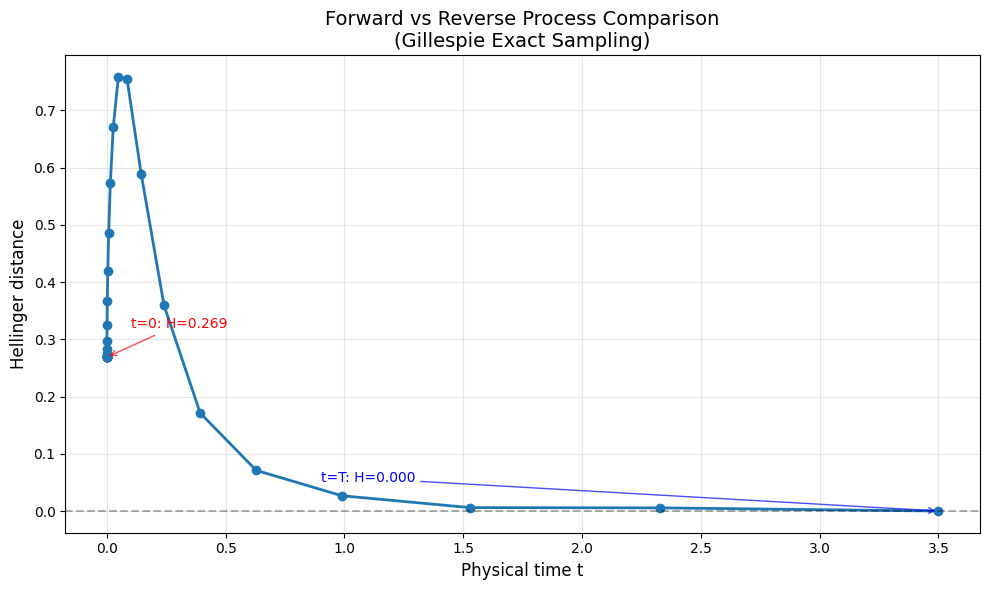


Experiment complete!


In [ ]:
if __name__ == "__main__":
    print("=" * 70)
    print("Gillespie Diffusion Experiment: Forward vs Reverse Comparison")
    print("=" * 70)
    
    # Setup parameters
    N = 10      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10    # Number of mixture components
    w = np.ones(r) / r
    
    # w = np.array([0.3, 0.5, 0.2])  # Mixture weights
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    
    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 250_000 # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    # checkpoint_times = np.linspace(0, T, 201)  # [0.0, 0.05, ..., 1.0]
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    samples = run_diffusion_experiment_with_gillespie(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Compute Hellinger distances
    print("\nComputing Hellinger distances...")
    distances = samples.compute_hellinger_distances('gillespie')
    
    # Display results
    print("\nHellinger distances at checkpoints:")
    for t in samples.times[::4]:  # Print every 4th checkpoint
        if t in distances:
            print(f"  t = {t:.3f}: H = {distances[t]:.4f}")
    
    # Final distance
    t_final = samples.times[0]  # t=0 (should be best match)
    print(f"\n*** Final Hellinger distance at t={t_final}: {distances[t_final]:.4f} ***")
    
    # Plot results
    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(samples.times, [distances[t] for t in samples.times], 'o-', linewidth=2, markersize=6)
    plt.xlabel('Physical time t', fontsize=12)
    plt.ylabel('Hellinger distance', fontsize=12)
    plt.title('Forward vs Reverse Process Comparison\n(Gillespie Exact Sampling)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Annotate key points
    t0 = samples.times[0]
    tT = samples.times[-1]
    plt.annotate(f't=0: H={distances[t0]:.3f}', 
                xy=(t0, distances[t0]), xytext=(0.1, distances[t0] + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red')
    plt.annotate(f't=T: H={distances[tT]:.3f}', 
                xy=(tT, distances[tT]), xytext=(0.9, distances[tT] + 0.05),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7),
                fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.savefig('gillespie_diffusion_results.png', dpi=150, bbox_inches='tight')
    print("Plot saved to: gillespie_diffusion_results.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("Experiment complete!")
    print("=" * 70)

# Experiment: Sampling with Tau-leaping


Parameters:
  N (dimensions) = 6
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 30000
  checkpoints    = 31

Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/30000
  Gillespie particle 10000/30000
  Gillespie particle 20000/30000
Running tau-leaping (tau=0.5) reverse process...
  Tau-leap particle 0/30000
  Tau-leap particle 10000/30000
  Tau-leap particle 20000/30000
Running tau-leaping (tau=0.1) reverse process...
  Tau-leap particle 0/30000
  Tau-leap particle 10000/30000
  Tau-leap particle 20000/30000
Running tau-leaping (tau=0.05) reverse process...
  Tau-leap particle 0/30000
  Tau-leap particle 10000/30000
  Tau-leap particle 20000/30000
Running tau-leaping (tau=0.01) reverse process...
  Tau-leap particle 0/30000
  Tau-leap particle 10000/30000
  Tau-leap particle 20000/30000
Running tau-leaping (tau=0.005) reverse process...
  Tau-leap particle 0/30000
  Tau-leap particle 10000

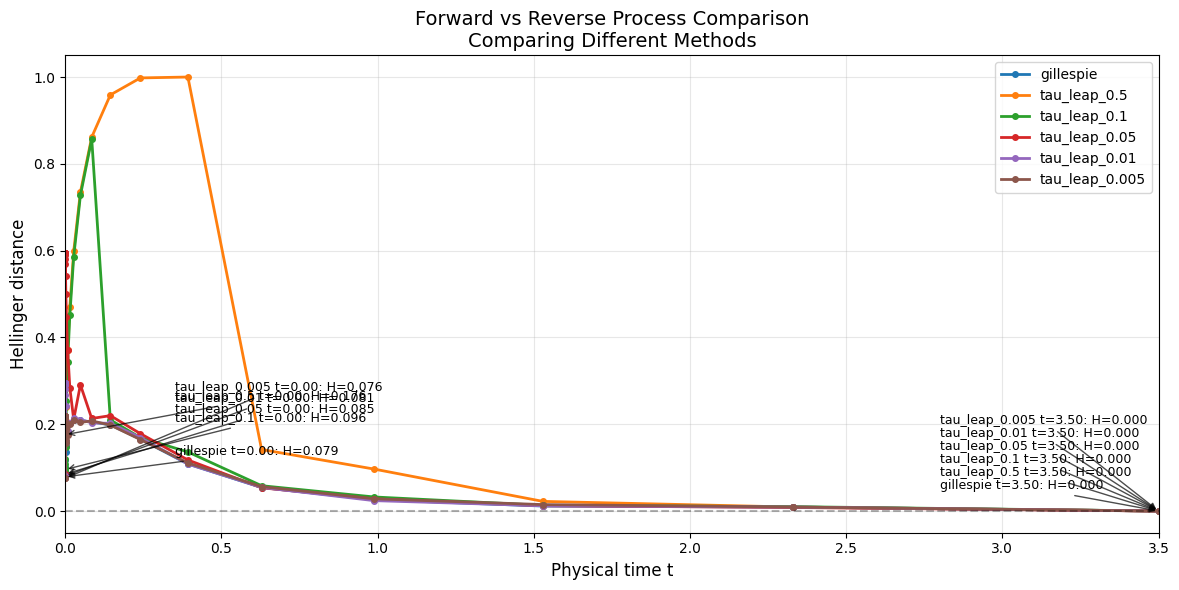


Experiment complete and saved!


In [250]:
# Usage example:
if __name__ == "__main__":
    N = 6      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10    # Number of mixture components
    w = np.ones(r) / r

    # w = np.array([0.3, 0.5, 0.2])  # Mixture weights
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)

    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 30_000 # Number of Monte Carlo samples

    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    # checkpoint_times = np.linspace(0, T, 201)  # [0.0, 0.05, ..., 1.0]

    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")

    # Run experiment
    print("\n" + "=" * 70)
    
    # Run forward once
    samples_2 = run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times)
    
    # # Add Gillespie
    add_gillespie_reverse(samples_2, w, mu, beta, T)
    
    # Add tau-leaping with different tau values
    add_tau_leap_reverse(samples_2, w, mu, beta, T, tau=0.5)
    add_tau_leap_reverse(samples_2, w, mu, beta, T, tau=0.1)
    add_tau_leap_reverse(samples_2, w, mu, beta, T, tau=0.05)
    add_tau_leap_reverse(samples_2, w, mu, beta, T, tau=0.01)
    add_tau_leap_reverse(samples_2, w, mu, beta, T, tau=0.005)
    
    # Compare all methods
    all_distances = samples_2.compute_all_hellinger_distances()
    

    # Prepare metadata
    experiment_metadata = {
        'N': N,
        'L': L,
        'r': r,
        'beta': beta,
        'T': T,
        'n_mc': n_mc,
        'tau_values': [0.5, 0.1, 0.05, 0.01, 0.005],
        'w': w.tolist(),
        'mu_shape': mu.shape,
        'checkpoint_formula': 'T * (u ** 12) where u = linspace(0, 1, 31)',
        'n_checkpoints': len(checkpoint_times),
        'methods': samples_2.list_methods(),
        'date': '2026-05-20',
        'notes': 'Gillespie vs tau-leaping comparison with 6 tau values'
    }
    
    # Save full data
    save_samples(samples_2, 'experiment_N8_L3_beta5_T3.5.pkl', metadata=experiment_metadata)
    
    # Save summary
    save_samples_summary(samples_2, 'experiment_N8_L3_beta5_T3.5_summary.json', 
                        metadata=experiment_metadata)
    
    # Plot and save figure
    plot_method_comparison(samples_2, filename='comparison_all_methods.png')
    
    print("\n" + "=" * 70)
    print("Experiment complete and saved!")
    print("=" * 70)



Generating plot for methods: ['gillespie', 'tau_leap_0.5', 'tau_leap_0.1', 'tau_leap_0.05', 'tau_leap_0.01', 'tau_leap_0.005']
Time range: [-0.100, 0.100]
Plot saved to: diffusion_comparison_all_methods.png


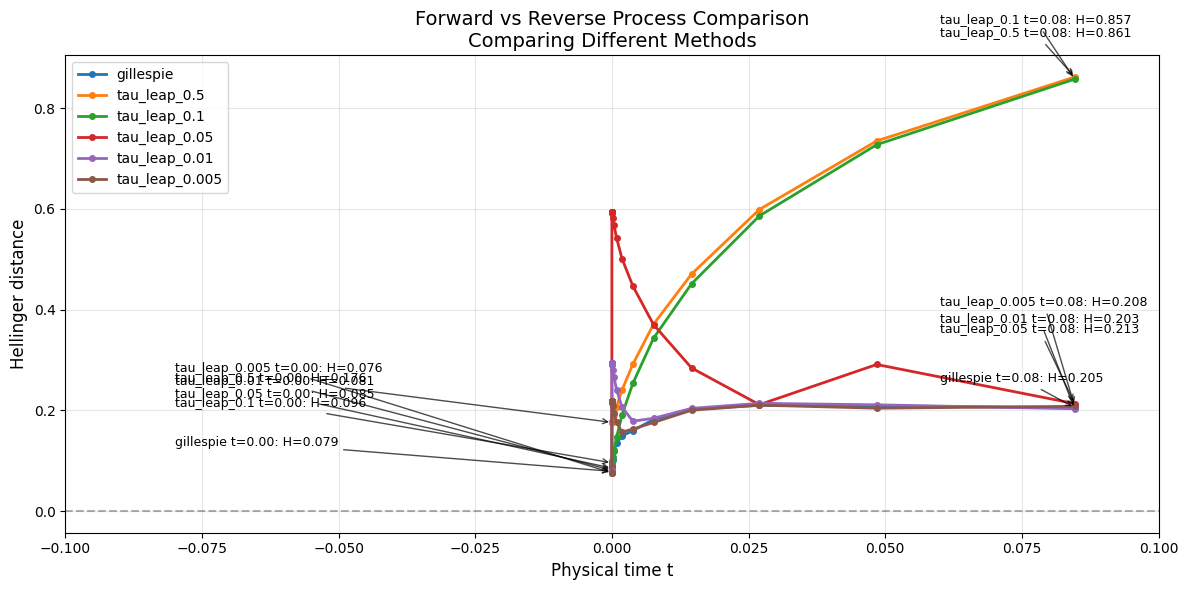

In [252]:
plot_method_comparison(samples_2, time_start=-0.1, time_end=0.1)



# Experiment: Tau-Leaping + Random Corrector

## $R^c = R + \hat{R}$ vs $R^c = R$

In [ ]:
# Usage example:
if __name__ == "__main__":
    N = 6      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10    # Number of mixture components
    w = np.ones(r) / r
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    
    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 10_000 # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    
    # Run forward once
    samples_3 = run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Add Gillespie (baseline)
    add_gillespie_reverse(samples_3, w, mu, beta, T)
    
    # Add tau-leaping WITHOUT corrector
    add_tau_leap_reverse(samples_3, w, mu, beta, T, tau=0.01, corrector=False)
    add_tau_leap_reverse(samples_3, w, mu, beta, T, tau=0.005, corrector=False)
    
    # Add tau-leaping WITH random masking corrector (forward + reverse)
    add_tau_leap_reverse(
        samples_3, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='random_masking',
        corrector_start=2.0,  # Apply corrector when t < 2.0
        corrector_hyperparameters={
            'n_corr': 5,
            'tau_c': 0.002,
            'apply_reverse': True
        }
    )
    
    add_tau_leap_reverse(
        samples_3, w, mu, beta, T, tau=0.005,
        corrector=True,
        corrector_method='random_masking',
        corrector_start=2.0,
        corrector_hyperparameters={
            'n_corr': 5,
            'tau_c': 0.002,
            'apply_reverse': True
        }
    )
    
    # Add tau-leaping with FORWARD-ONLY corrector (no reverse step)
    add_tau_leap_reverse(
        samples_3, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='random_masking',
        corrector_start=2.0,
        corrector_hyperparameters={
            'n_corr': 5,  # More steps since no reverse
            'tau_c': 0.002,
            'apply_reverse': False
        }
    )
    
    # Compare all methods
    all_distances = samples_3.compute_all_hellinger_distances()
    
    # Prepare metadata
    experiment_metadata = {
        'N': N,
        'L': L,
        'r': r,
        'beta': beta,
        'T': T,
        'n_mc': n_mc,
        'tau_values': [0.01, 0.005],
        'corrector_configs': [
            {'tau': 0.01, 'corrector': False},
            {'tau': 0.005, 'corrector': False},
            {'tau': 0.01, 'corrector': 'random_masking', 'n_corr': 5, 'tau_c': 0.002, 'apply_reverse': True},
            {'tau': 0.005, 'corrector': 'random_masking', 'n_corr': 5, 'tau_c': 0.002, 'apply_reverse': True},
            {'tau': 0.01, 'corrector': 'random_masking_forward_only', 'n_corr': 5, 'tau_c': 0.002, 'apply_reverse': False}
        ],
        'w': w.tolist(),
        'mu_shape': mu.shape,
        'checkpoint_formula': 'T * (u ** 12) where u = linspace(0, 1, 31)',
        'n_checkpoints': len(checkpoint_times),
        'methods': samples_3.list_methods(),
        'date': '2026-05-20',
        'notes': 'Comparing Gillespie, tau-leaping, and tau-leaping with random masking corrector'
    }
    
    # Save full data
    save_samples(samples_3, 'experiment_corrector_comparison.pkl', metadata=experiment_metadata)
    
    # Save summary
    save_samples_summary(samples_3, 'experiment_corrector_comparison_summary.json', 
                        metadata=experiment_metadata)
    


Parameters:
  N (dimensions) = 6
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 10000
  checkpoints    = 31




Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only']
Time range: [0.000, 3.500]
Plot saved to: corrector_all_methods_full.png


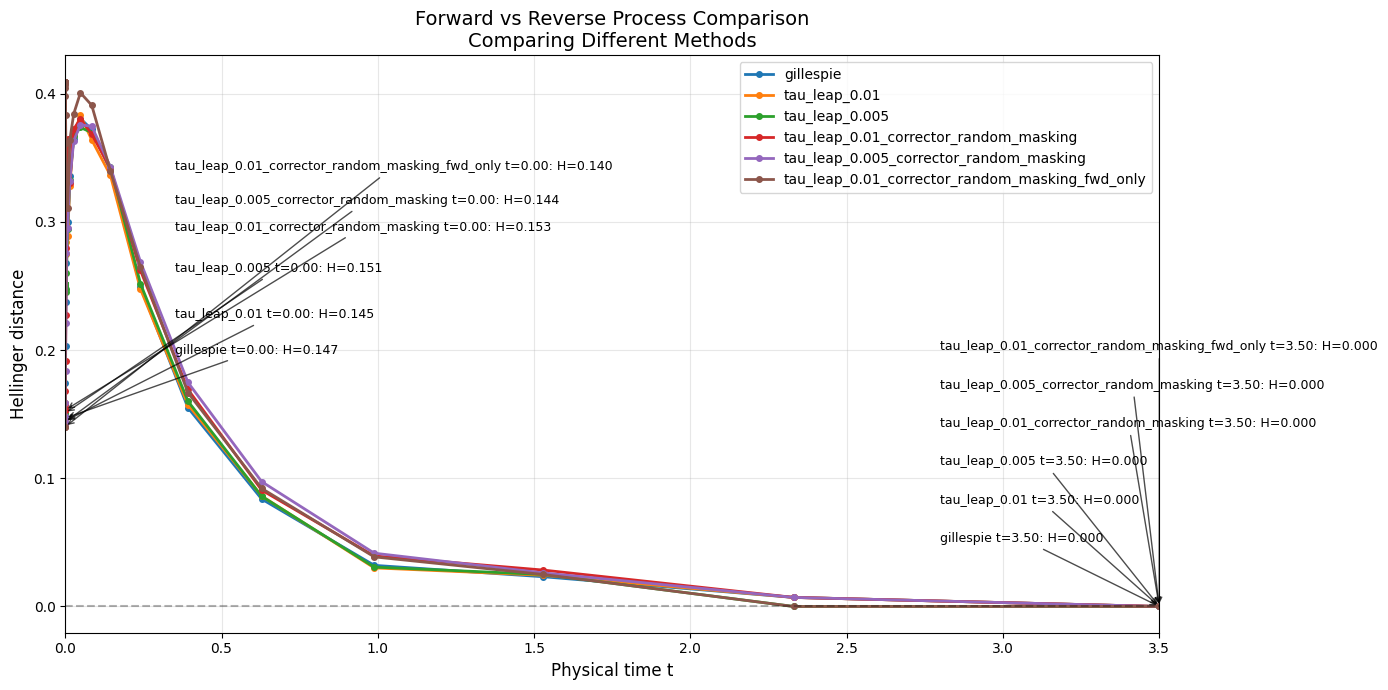


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only']
Time range: [-0.100, 0.500]
Plot saved to: corrector_early_times_0_to_0.5.png


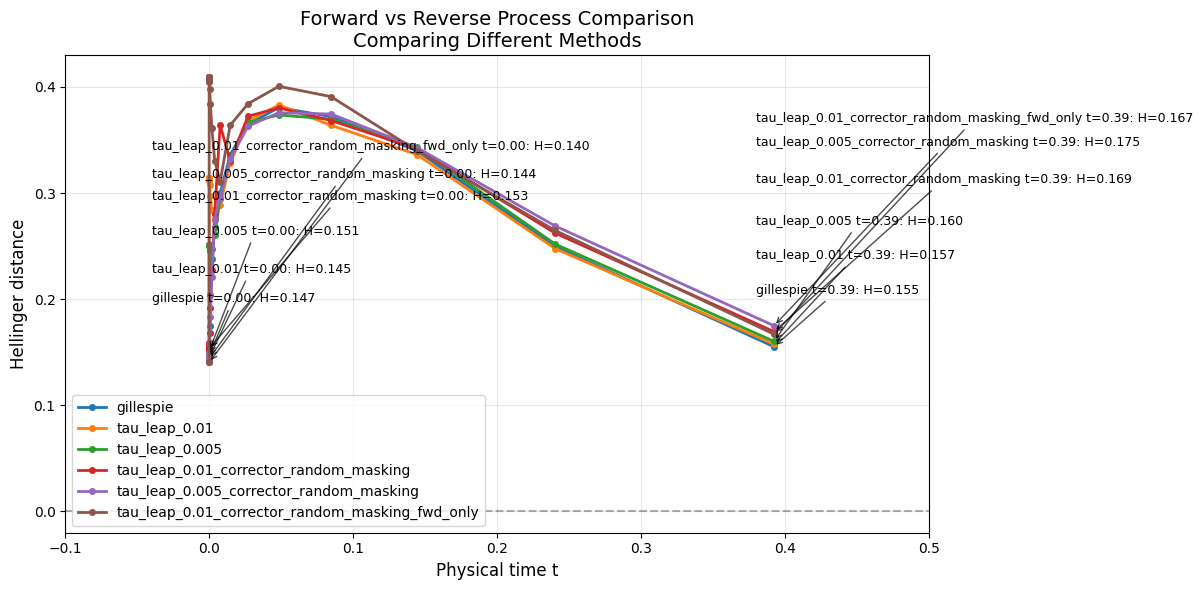


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only']
Time range: [-0.100, 0.200]
Plot saved to: corrector_very_early_0_to_0.2.png


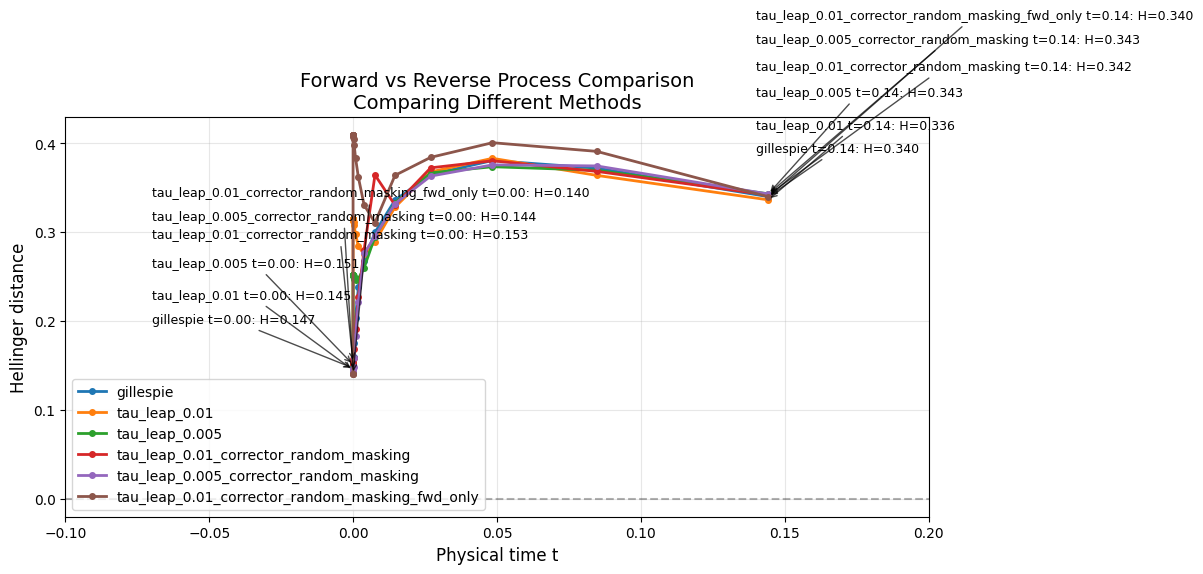


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.01_corrector_random_masking']
Time range: [-0.100, 0.500]
Plot saved to: tau_0.01_corrector_comparison.png


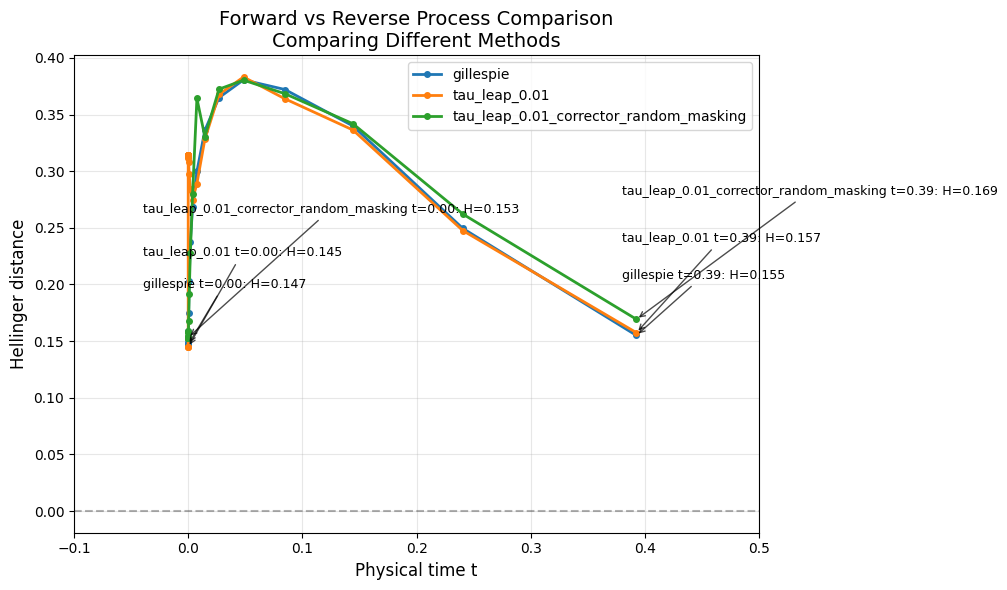


Generating plot for methods: ['gillespie', 'tau_leap_0.005', 'tau_leap_0.005_corrector_random_masking']
Time range: [-0.100, 0.500]
Plot saved to: tau_0.005_corrector_comparison.png


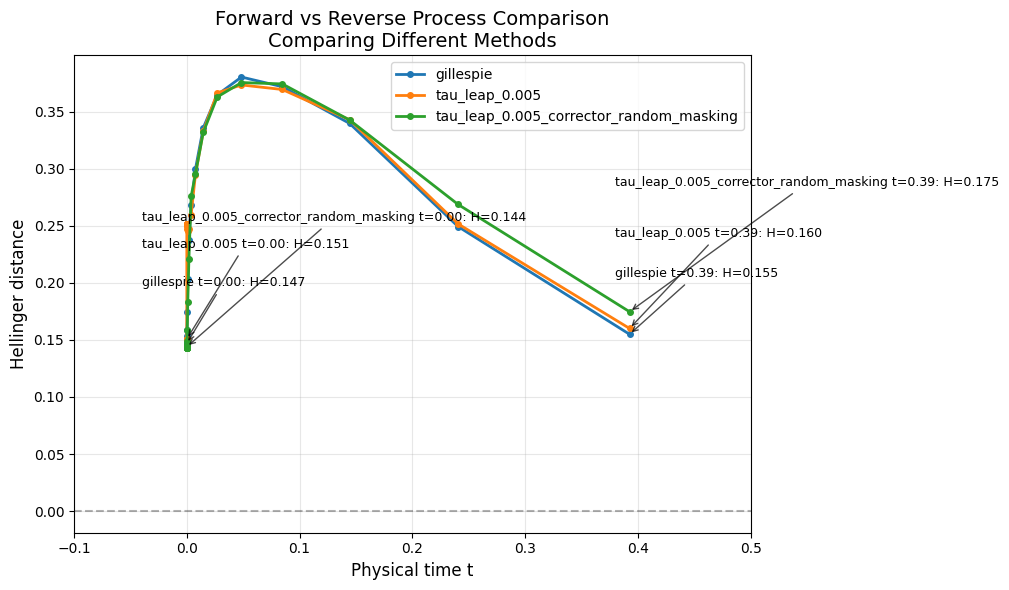


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only']
Time range: [-0.100, 0.300]
Plot saved to: forward_only_vs_full_corrector.png


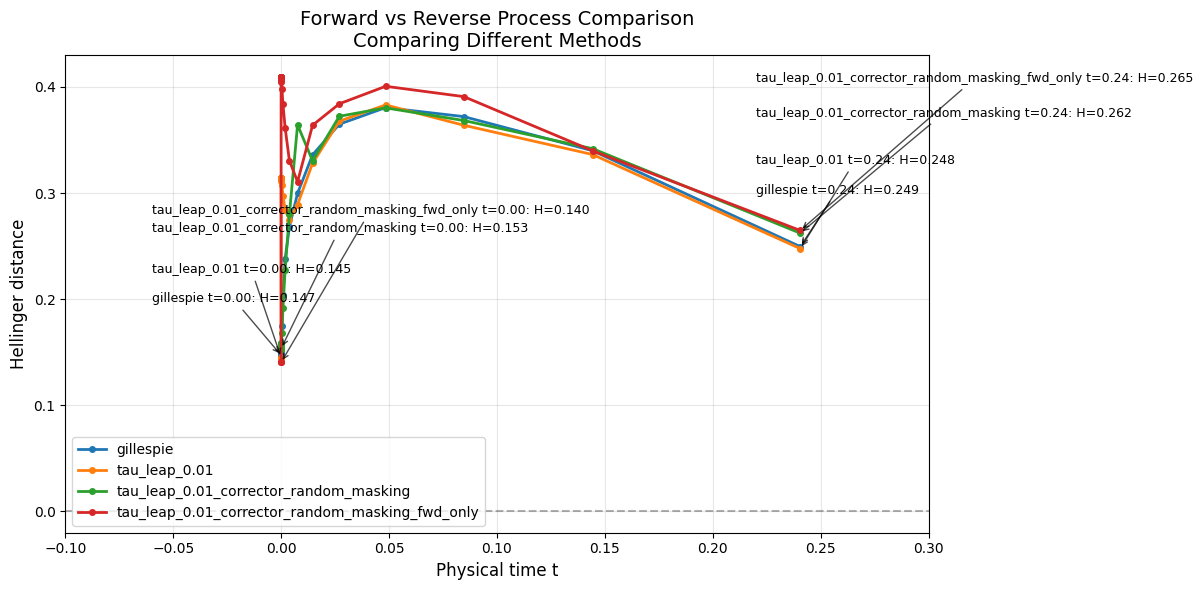


Generating plot for methods: ['gillespie', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005_corrector_random_masking']
Time range: [-0.100, 0.500]
Plot saved to: corrector_different_tau.png


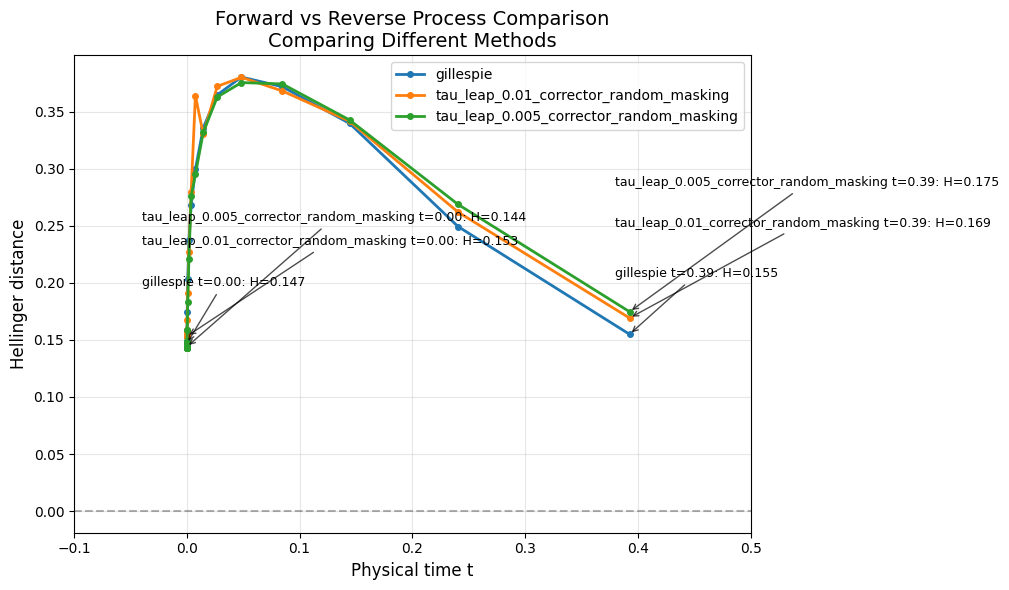


Generating plot for methods: ['tau_leap_0.01', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005', 'tau_leap_0.005_corrector_random_masking']
Time range: [-0.100, 0.300]
Plot saved to: tau_leap_only_corrector_effect.png


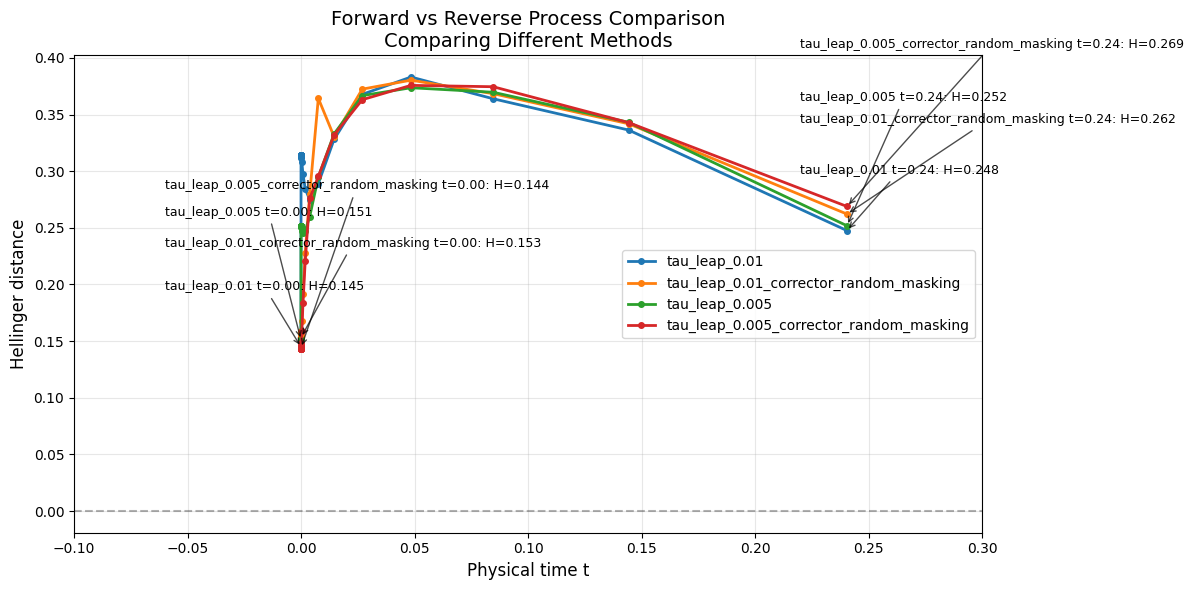


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only']
Time range: [-0.100, 0.100]
Plot saved to: extreme_zoom_0_to_0.1.png


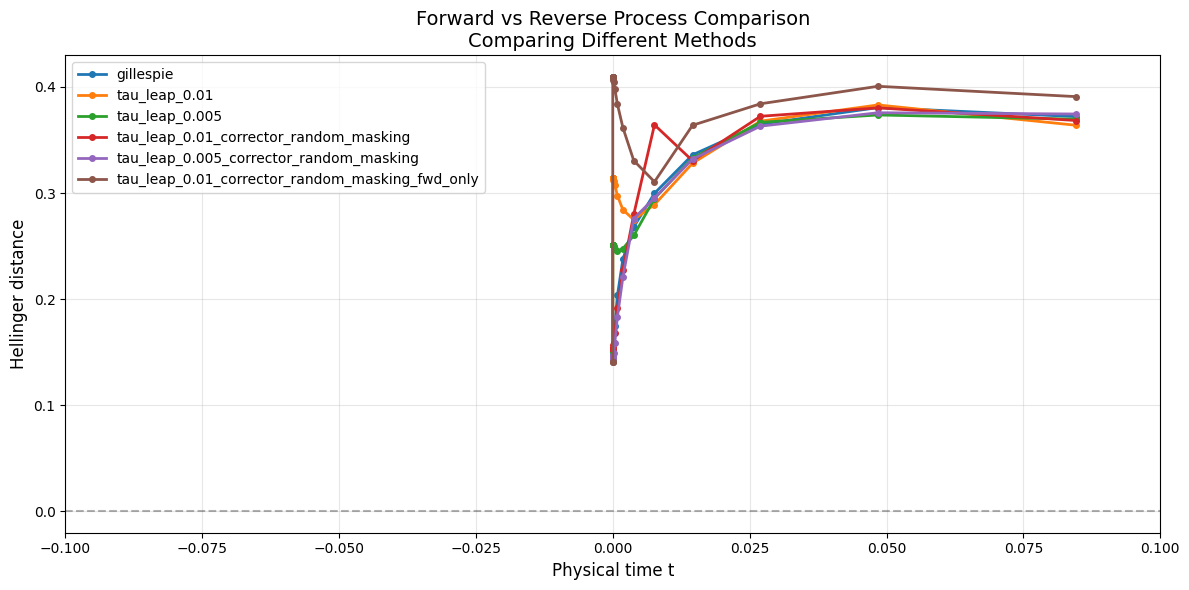


Generating plot for methods: ['tau_leap_0.01_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only', 'tau_leap_0.005_corrector_random_masking']
Time range: [-0.100, 0.400]
Plot saved to: all_corrector_variants.png


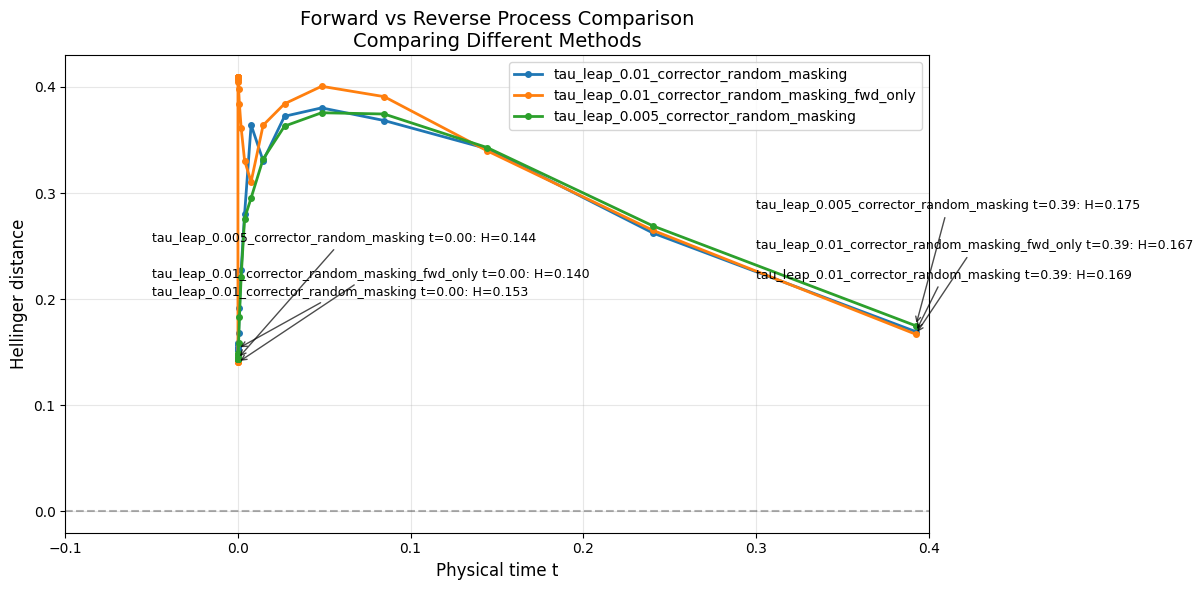


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_random_masking', 'tau_leap_0.005_corrector_random_masking', 'tau_leap_0.01_corrector_random_masking_fwd_only']
Time range: [0.000, 3.500]
Plot saved to: all_methods_no_annotations.png


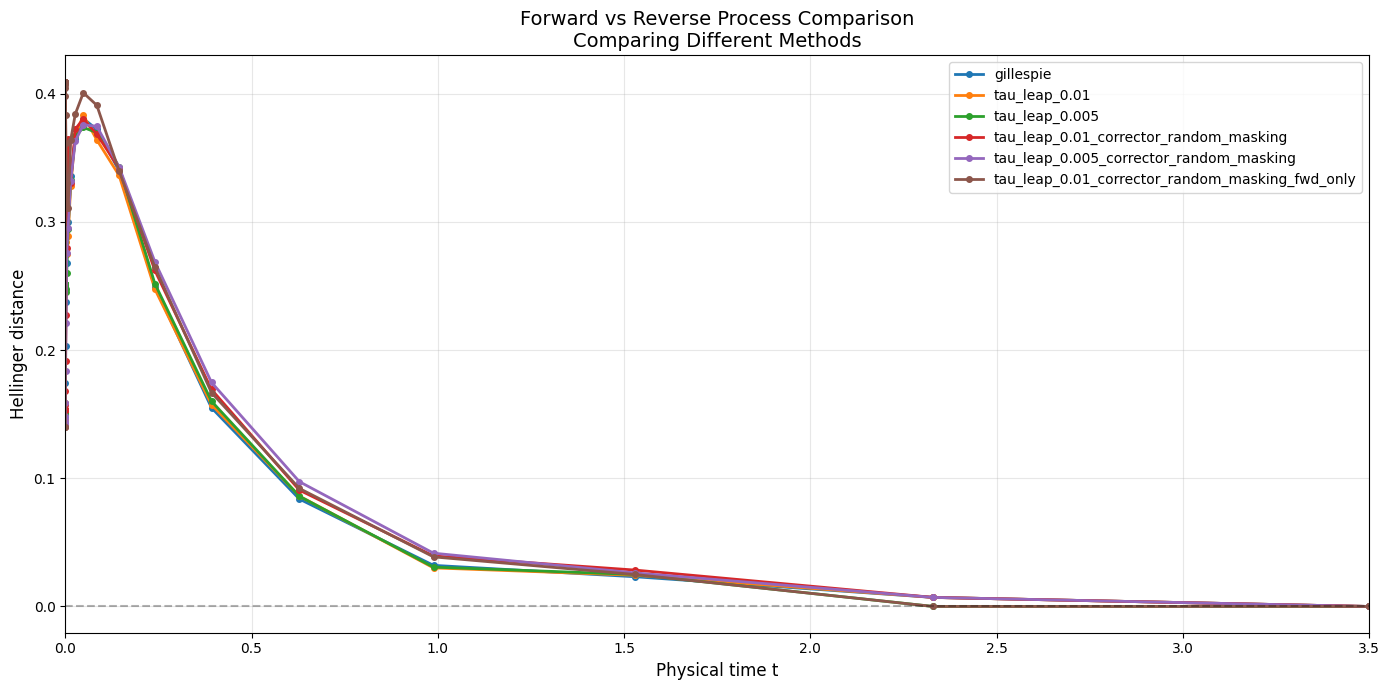


Hellinger distances at t=0:
gillespie                                         : H(t=0) = 0.1469
tau_leap_0.01                                     : H(t=0) = 0.1447
tau_leap_0.005                                    : H(t=0) = 0.1508
tau_leap_0.01_corrector_random_masking            : H(t=0) = 0.1532
tau_leap_0.005_corrector_random_masking           : H(t=0) = 0.1439
tau_leap_0.01_corrector_random_masking_fwd_only   : H(t=0) = 0.1402


In [ ]:
# 1. Overview: All methods, full time range
plot_method_comparison(
    samples_3, 
    filename='corrector_all_methods_full.png',
    figsize=(14, 7)
)

# 2. Focus on early times (0 to 0.5) - where corrector should help most
plot_method_comparison(
    samples_3,
    time_start=-0.1,
    time_end=0.5,
    filename='corrector_early_times_0_to_0.5.png',
    figsize=(12, 6)
)

# 3. Very early times (0 to 0.2) - zoom in near t=0
plot_method_comparison(
    samples_3,
    time_start=-0.10,
    time_end=0.2,
    filename='corrector_very_early_0_to_0.2.png',
    figsize=(12, 6)
)

# 4. Compare tau=0.01 with and without corrector
plot_method_comparison(
    samples_3,
    methods=['gillespie', 'tau_leap_0.01', 'tau_leap_0.01_corrector_random_masking'],
    time_start=-0.10,
    time_end=0.5,
    filename='tau_0.01_corrector_comparison.png',
    figsize=(10, 6)
)

# 5. Compare tau=0.005 with and without corrector
plot_method_comparison(
    samples_3,
    methods=['gillespie', 'tau_leap_0.005', 'tau_leap_0.005_corrector_random_masking'],
    time_start=-0.10,
    time_end=0.5,
    filename='tau_0.005_corrector_comparison.png',
    figsize=(10, 6)
)

# 6. Compare forward-only vs full corrector for tau=0.01
plot_method_comparison(
    samples_3,
    methods=[
        'gillespie',
        'tau_leap_0.01',
        'tau_leap_0.01_corrector_random_masking',
        'tau_leap_0.01_corrector_random_masking_fwd_only'
    ],
    time_start=-0.10,
    time_end=0.3,
    filename='forward_only_vs_full_corrector.png',
    figsize=(12, 6)
)

# 7. Compare different tau values (all with corrector)
plot_method_comparison(
    samples_3,
    methods=[
        'gillespie',
        'tau_leap_0.01_corrector_random_masking',
        'tau_leap_0.005_corrector_random_masking'
    ],
    time_start=-0.1,
    time_end=0.5,
    filename='corrector_different_tau.png',
    figsize=(10, 6)
)

# 8. Just tau-leap methods (no Gillespie) to see corrector effect clearly
plot_method_comparison(
    samples_3,
    methods=[
        'tau_leap_0.01',
        'tau_leap_0.01_corrector_random_masking',
        'tau_leap_0.005',
        'tau_leap_0.005_corrector_random_masking'
    ],
    time_start=-0.1,
    time_end=0.3,
    filename='tau_leap_only_corrector_effect.png',
    figsize=(12, 6)
)

# 9. Extreme zoom: first 0.1 time units
plot_method_comparison(
    samples_3,
    time_start=-0.1,
    time_end=0.1,
    filename='extreme_zoom_0_to_0.1.png',
    figsize=(12, 6),
    show_annotations=False  # Too crowded with annotations
)

# 10. Compare all corrector variants at early times
plot_method_comparison(
    samples_3,
    methods=[
        'tau_leap_0.01_corrector_random_masking',
        'tau_leap_0.01_corrector_random_masking_fwd_only',
        'tau_leap_0.005_corrector_random_masking'
    ],
    time_start=-0.1,
    time_end=0.4,
    filename='all_corrector_variants.png',
    figsize=(12, 6)
)

# 11. Full picture but without annotations (cleaner for many methods)
plot_method_comparison(
    samples_3,
    show_annotations=False,
    filename='all_methods_no_annotations.png',
    figsize=(14, 7)
)

# 12. Print Hellinger distances at t=0 for comparison
print("\n" + "="*70)
print("Hellinger distances at t=0:")
print("="*70)
all_distances = samples_3.compute_all_hellinger_distances()
t0 = samples_3.times[0]
for method in samples_3.list_methods():
    print(f"{method:50s}: H(t=0) = {all_distances[method][t0]:.4f}")


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.01_corrector_random_masking_fwd_only', 'tau_leap_0.01_corrector_random_masking']
Time range: [-0.100, 0.200]
Plot saved to: all_corrector_variants.png


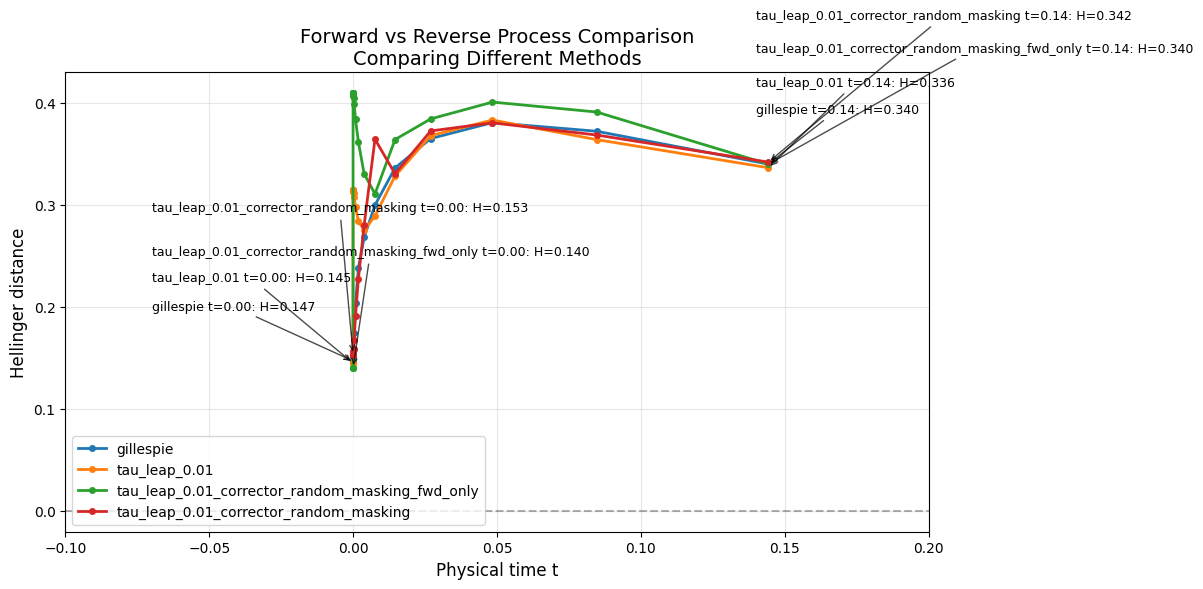

In [ ]:
# 10. Compare all corrector variants at early times
plot_method_comparison(
    samples_3,
    methods=[
        'gillespie',
        'tau_leap_0.01',
        'tau_leap_0.01_corrector_random_masking_fwd_only',
        'tau_leap_0.01_corrector_random_masking'
    ],
    time_start=-0.1,
    time_end=0.2,
    filename='all_corrector_variants.png',
    figsize=(12, 6)
)

# Experiment: Tau-Leaping + PRISM


Parameters:
  N (dimensions) = 4
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 3.5
  n_mc (samples) = 50
  checkpoints    = 31

Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/50
Running tau-leaping (tau=0.01) reverse process...
  Tau-leap particle 0/50
Running tau-leaping (tau=0.005) reverse process...
  Tau-leap particle 0/50
Running tau-leaping (tau=0.01) reverse process...
  With corrector: PRISM, start=2.0
  Corrector hyperparameters: {'eta': 0.2}
  Tau-leap particle 0/50
Running tau-leaping (tau=0.01) reverse process...
  With corrector: PRISM, start=2.0
  Corrector hyperparameters: {'eta': 0.02}
  Tau-leap particle 0/50
Running tau-leaping (tau=0.01) reverse process...
  With corrector: PRISM, start=2.0
  Corrector hyperparameters: {'eta': 0.002}
  Tau-leap particle 0/50
Running tau-leaping (tau=0.005) reverse process...
  With corrector: PRISM, start=2.0
  Corrector hyperparameters: {'eta': 0.02}
  T

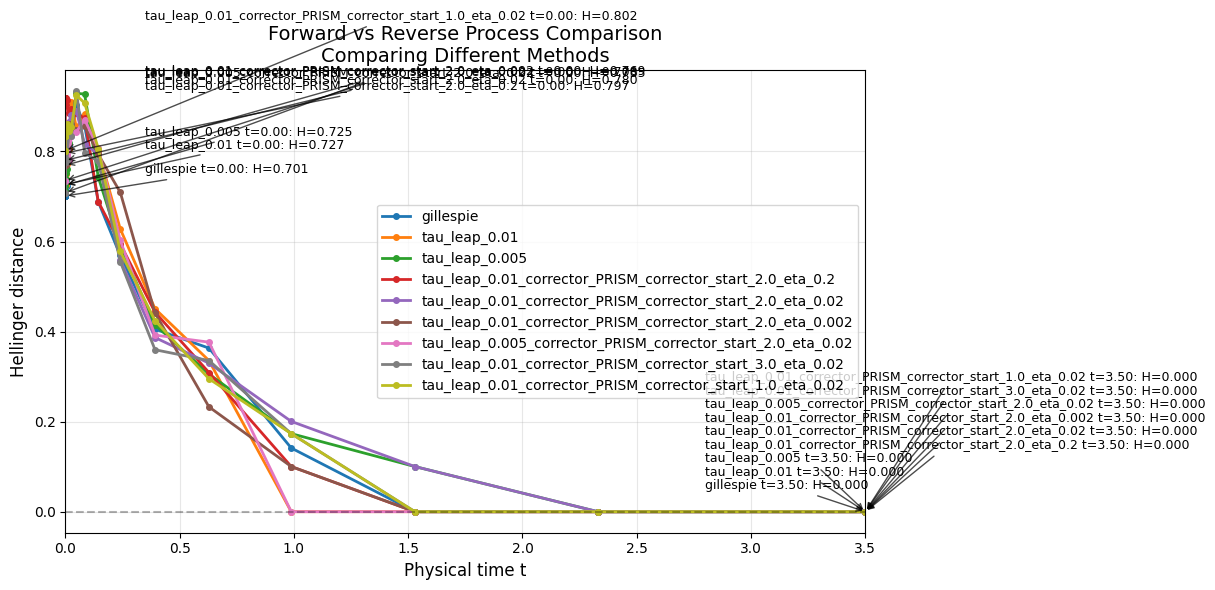


Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_PRISM_corrector_start_2.0_eta_0.2', 'tau_leap_0.01_corrector_PRISM_corrector_start_2.0_eta_0.02', 'tau_leap_0.01_corrector_PRISM_corrector_start_2.0_eta_0.002', 'tau_leap_0.005_corrector_PRISM_corrector_start_2.0_eta_0.02', 'tau_leap_0.01_corrector_PRISM_corrector_start_3.0_eta_0.02', 'tau_leap_0.01_corrector_PRISM_corrector_start_1.0_eta_0.02']
Time range: [0.000, 0.500]
Plot saved to: prism_corrector_comparison_zoom.png


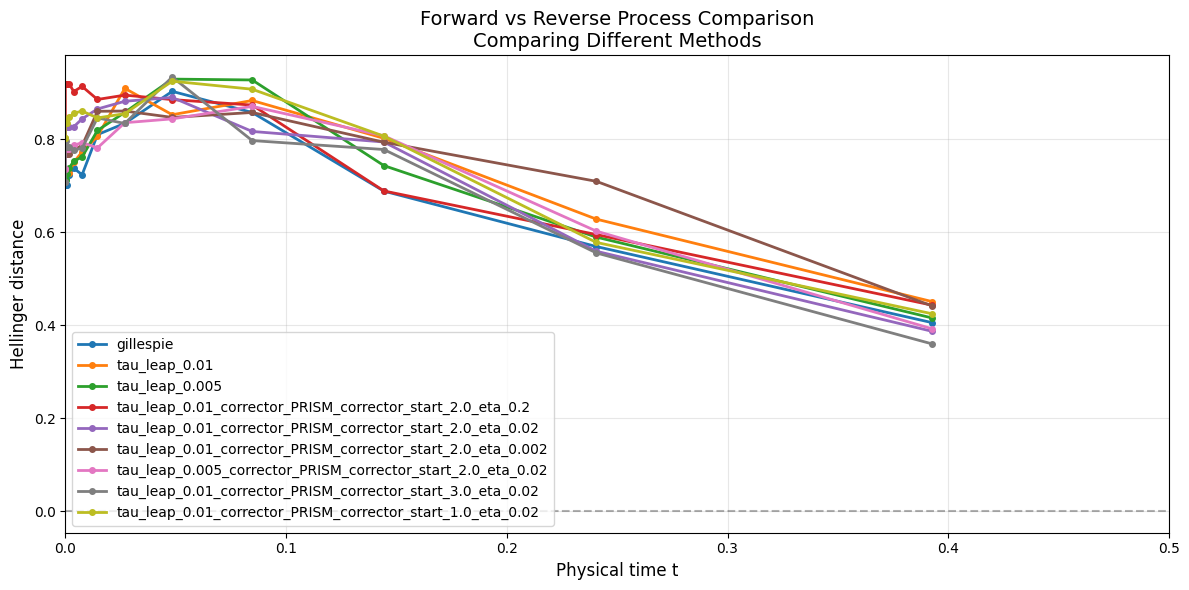

In [38]:
# Usage example for PRISM corrector:
if __name__ == "__main__":
    N = 4      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10     # Number of mixture components
    w = np.ones(r) / r
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    beta = 5.0  # Masking rate
    T = 3.5    # Terminal time
    n_mc = 50 # n_mc = 100_000  # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    u = np.linspace(0, 1, 31)
    checkpoint_times = T * (u ** 12)  # More checkpoints near t=0
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    
    # Run forward once
    samples_prism = run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Add Gillespie (baseline)
    add_gillespie_reverse(samples_prism, w, mu, beta, T)
    
    # Add tau-leaping WITHOUT corrector (baseline)
    add_tau_leap_reverse(samples_prism, w, mu, beta, T, tau=0.01, corrector=False)
    add_tau_leap_reverse(samples_prism, w, mu, beta, T, tau=0.005, corrector=False)
    
    # Add tau-leaping WITH PRISM corrector (fixed eta)
    add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=2.0,  # Apply corrector when t < 2.0
        corrector_hyperparameters={
            'eta': 0.2,  # Fixed remasking probability
        }
    )
    
    # Try different eta values
    add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=2.0,
        corrector_hyperparameters={
            'eta': 0.02,  # Lower remasking rate
        }
    )
    
    add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=2.0,
        corrector_hyperparameters={
            'eta': 0.002,  
        }
    )
    
    # Try with smaller tau
    add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.005,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=2.0,
        corrector_hyperparameters={
            'eta': 0.02,
        }
    )
    
    # Try starting corrector earlier
    add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=3.0,  # Start earlier (closer to T)
        corrector_hyperparameters={
            'eta': 0.02,
        }
    )
    
    # Try starting corrector later
    add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=1.0,  # Start later (closer to 0)
        corrector_hyperparameters={
            'eta': 0.02,
        }
    )
    
    # Compare all methods
    all_distances = samples_prism.compute_all_hellinger_distances()
    
    # Prepare metadata
    experiment_metadata = {
        'N': N,
        'L': L,
        'r': r,
        'beta': beta,
        'T': T,
        'n_mc': n_mc,
        'tau_values': [0.01, 0.005],
        'corrector_configs': [
            {'tau': 0.01, 'corrector': False},
            {'tau': 0.005, 'corrector': False},
            {'tau': 0.01, 'corrector': 'PRISM', 'eta': 0.2, 'corrector_start': 2.0},
            {'tau': 0.01, 'corrector': 'PRISM', 'eta': 0.02, 'corrector_start': 2.0},
            {'tau': 0.01, 'corrector': 'PRISM', 'eta': 0.002, 'corrector_start': 2.0},
            {'tau': 0.005, 'corrector': 'PRISM', 'eta': 0.02, 'corrector_start': 2.0},
            {'tau': 0.01, 'corrector': 'PRISM', 'eta': 0.02, 'corrector_start': 3.0},
            {'tau': 0.01, 'corrector': 'PRISM', 'eta': 0.02, 'corrector_start': 1.0},
        ],
        'w': w.tolist(),
        'mu_shape': mu.shape,
        'checkpoint_formula': 'T * (u ** 12) where u = linspace(0, 1, 31)',
        'n_checkpoints': len(checkpoint_times),
        'methods': samples_prism.list_methods(),
        'date': '2026-05-22',
        'notes': 'Comparing Gillespie, tau-leaping, and PRISM corrector with various eta and corrector_start values'
    }
    
    # Save full data
    save_samples(samples_prism, 'experiment_prism_corrector.pkl', metadata=experiment_metadata)
    
    # Save summary
    save_samples_summary(samples_prism, 'experiment_prism_corrector_summary.json', 
                        metadata=experiment_metadata)
    
    # Plot comparison
    plot_method_comparison(
        samples_prism,
        methods=None,  # Plot all methods
        time_start=0.0,
        time_end=T,
        filename='prism_corrector_comparison.png',
        show_annotations=True
    )
    
    # Plot zoomed in near t=0 (where differences are most visible)
    plot_method_comparison(
        samples_prism,
        methods=None,
        time_start=0.0,
        time_end=0.5,
        filename='prism_corrector_comparison_zoom.png',
        show_annotations=False
    )

In [21]:
    # Try starting corrector later
add_tau_leap_reverse(
        samples_prism, w, mu, beta, T, tau=0.01,
        corrector=True,
        corrector_method='PRISM',
        corrector_start=1.0,  # Start later (closer to 0)
        corrector_hyperparameters={
            'eta': 0.02,
        }
    )

Running tau-leaping (tau=0.01) reverse process...
  With corrector: PRISM, start=1.0
  Corrector hyperparameters: {'eta': 0.02}
  Tau-leap particle 0/100000
  Tau-leap particle 10000/100000
  Tau-leap particle 20000/100000
  Tau-leap particle 30000/100000
  Tau-leap particle 40000/100000
  Tau-leap particle 50000/100000
  Tau-leap particle 60000/100000
  Tau-leap particle 70000/100000
  Tau-leap particle 80000/100000
  Tau-leap particle 90000/100000



Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.005', 'tau_leap_0.01_corrector_PRISM', 'tau_leap_0.005_corrector_PRISM']
Time range: [0.000, 3.500]
Plot saved to: prism_corrector_comparison.png


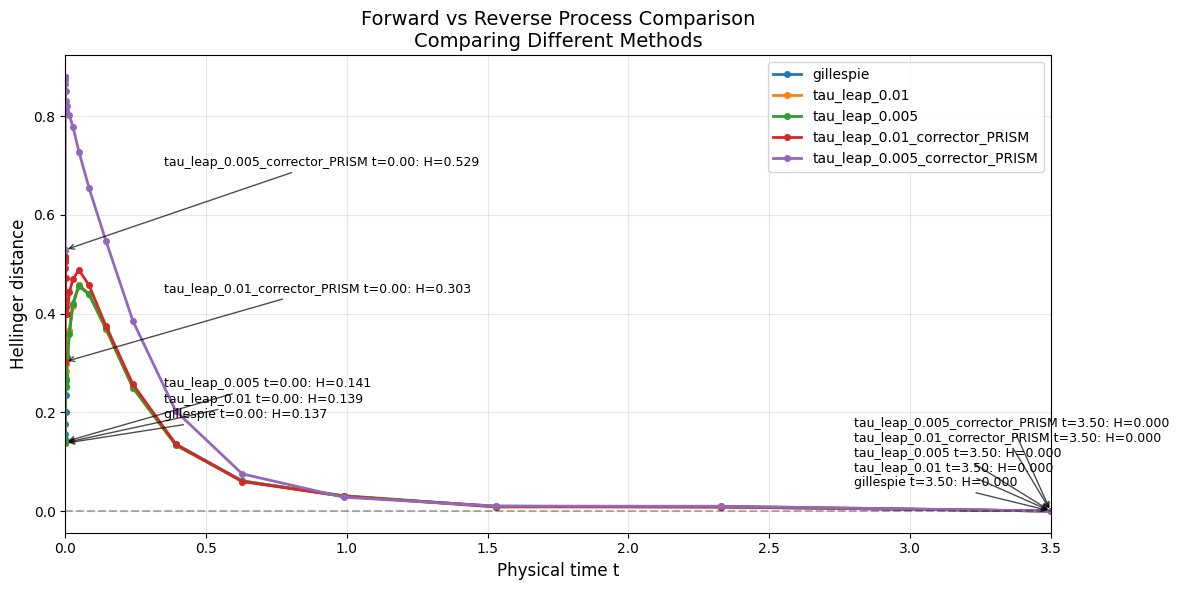

In [23]:
    # Plot comparison
plot_method_comparison(
        samples_prism,
        methods=None,  # Plot all methods
        time_start=0.0,
        time_end=T,
        filename='prism_corrector_comparison.png',
        show_annotations=True
    )

# Experiment: Tau-Leaping + Informed Corrector